**1. Setup & Imports**

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel
from PIL import Image
from collections import Counter


**2. Paths to Dataset**

In [2]:
IMG_PATH = "Lung_CT_nodule/images"
MASK_PATH = "Lung_CT_nodule/masks"
TEST_IMG_PATH = "Lung_CT_nodule/t_images"
TEST_MASK_PATH = "Lung_CT_nodule/t_masks"


**3. Dataset Alignment & Size Diagnostics**

In [3]:
import random
import tensorflow as tf

def check_dataset_alignment(image_dir, mask_dir):
    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])
    mask_files  = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])

    image_names = set([os.path.splitext(f)[0] for f in image_files])
    mask_names  = set([os.path.splitext(f)[0] for f in mask_files])

    missing_masks  = image_names - mask_names
    missing_images = mask_names - image_names

    print(f"Total images: {len(image_files)}")
    print(f"Total masks : {len(mask_files)}")
    print(f"Aligned pairs: {len(image_names & mask_names)}")
    print(f"Images without masks: {len(missing_masks)}")
    print(f"Masks without images: {len(missing_images)}")

    if missing_masks:
        print("⚠️ Images without masks (first 5):", list(missing_masks)[:5])
    if missing_images:
        print("⚠️ Masks without images (first 5):", list(missing_images)[:5])


def check_size_mismatches(image_dir, mask_dir, sample=20, full_scan=False):
    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])
    mask_files  = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])

    image_names = {os.path.splitext(f)[0]: f for f in image_files}
    mask_names  = {os.path.splitext(f)[0]: f for f in mask_files}
    common = sorted(set(image_names.keys()) & set(mask_names.keys()))

    if not common:
        print("No aligned pairs found.")
        return

    if full_scan:
        pairs = common
    else:
        pairs = random.sample(common, min(sample, len(common)))

    mismatches = []
    for name in pairs:
        img_path = os.path.join(image_dir, image_names[name])
        mask_path = os.path.join(mask_dir, mask_names[name])

        img = tf.io.decode_image(tf.io.read_file(img_path)).shape[:2]
        mask = tf.io.decode_image(tf.io.read_file(mask_path)).shape[:2]

        if img != mask:
            mismatches.append((name, img, mask))

    print(f"Checked {len(pairs)} pairs, mismatches: {len(mismatches)}")
    if mismatches:
        print("⚠️ Example mismatches:", mismatches[:5])


# ---- Run diagnostics ----
print("TRAIN dataset check:")
check_dataset_alignment(IMG_PATH, MASK_PATH)
check_size_mismatches(IMG_PATH, MASK_PATH, sample=20, full_scan=False)

print("\nTEST dataset check:")
check_dataset_alignment(TEST_IMG_PATH, TEST_MASK_PATH)
check_size_mismatches(TEST_IMG_PATH, TEST_MASK_PATH, sample=20, full_scan=False)


TRAIN dataset check:
Total images: 2027
Total masks : 2028
Aligned pairs: 2027
Images without masks: 0
Masks without images: 1
⚠️ Masks without images (first 5): ['2504']
Checked 20 pairs, mismatches: 0

TEST dataset check:
Total images: 507
Total masks : 507
Aligned pairs: 507
Images without masks: 0
Masks without images: 0
Checked 20 pairs, mismatches: 0


# **4. Preprocessing & Augmentation**

In [4]:
IMG_SIZE = 128

def preprocess_image(image):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image

def preprocess_mask(mask):
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask, tf.float32)
    return tf.where(mask > 0.5, 1.0, 0.0)

def augment_image_and_mask(image, mask, seed=(1, 2)):
    # convert to proper 2D int32 seeds
    seed = tf.constant(seed, dtype=tf.int32)

    # use different variations by offsetting the two elements
    seed1 = seed
    seed2 = seed + tf.constant([1, 0], dtype=tf.int32)
    seed3 = seed + tf.constant([2, 0], dtype=tf.int32)

    # flips
    image = tf.image.stateless_random_flip_left_right(image, seed1)
    mask  = tf.image.stateless_random_flip_left_right(mask, seed1)

    image = tf.image.stateless_random_flip_up_down(image, seed2)
    mask  = tf.image.stateless_random_flip_up_down(mask, seed2)

    # brightness
    image = tf.image.stateless_random_brightness(image, 0.1, seed=seed3)

    return image, mask

def load_image_mask(image_path, mask_path, seed=(1, 2)):
    image = tf.io.decode_jpeg(tf.io.read_file(image_path), channels=3)
    mask  = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)

    image = preprocess_image(image)
    mask = preprocess_mask(mask)

    return augment_image_and_mask(image, mask, seed)


**Cell 5 Dataset Loader with Alignment**

In [5]:
def create_dataset(image_dir, mask_dir, batch_size=16, shuffle=True):
    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])
    mask_files  = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])

    image_names = {os.path.splitext(f)[0]: f for f in image_files}
    mask_names  = {os.path.splitext(f)[0]: f for f in mask_files}
    common = sorted(set(image_names.keys()) & set(mask_names.keys()))

    aligned_images = [os.path.join(image_dir, image_names[name]) for name in common]
    aligned_masks  = [os.path.join(mask_dir, mask_names[name]) for name in common]

    print(f"Using {len(aligned_images)} aligned pairs from {image_dir} and {mask_dir}")

    ds = tf.data.Dataset.from_tensor_slices((aligned_images, aligned_masks))
    ds = ds.map(lambda x, y: load_image_mask(x, y), num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=100)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Now create datasets safely
train_ds = create_dataset(IMG_PATH, MASK_PATH)
val_ds   = create_dataset(TEST_IMG_PATH, TEST_MASK_PATH, shuffle=False)


Using 2027 aligned pairs from Lung_CT_nodule/images and Lung_CT_nodule/masks
Using 507 aligned pairs from Lung_CT_nodule/t_images and Lung_CT_nodule/t_masks


**DLU Activation function**

In [6]:
from tensorflow.keras import layers, models

# --- Custom Trainable DLU ---
class DLU(layers.Layer):
    def __init__(self, beta_init=0.0, **kwargs):
        super(DLU, self).__init__(**kwargs)
        self.beta_init = beta_init

    def build(self, input_shape):
        self.beta = self.add_weight(
            name="beta",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.beta_init),
            trainable=True,
            constraint=tf.keras.constraints.MinMaxNorm(min_value= 0, max_value=0.01)
        )
        super(DLU, self).build(input_shape)

    def call(self, inputs):
        return tf.maximum(inputs, self.beta * inputs)

    def get_config(self):
        config = super(DLU, self).get_config()
        config.update({"beta_init": self.beta_init})
        return config





**Litnet with LeakyReLU**

In [7]:
from tensorflow.keras import layers, models

def UNet_LeakyReLU(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    conv1 = layers.Conv2D(32, 3, padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.LeakyReLU(alpha=0.1)(conv1)
    conv1 = layers.Conv2D(32, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.LeakyReLU(alpha=0.1)(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.LeakyReLU(alpha=0.1)(conv2)
    conv2 = layers.Conv2D(64, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.LeakyReLU(alpha=0.1)(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.LeakyReLU(alpha=0.1)(conv3)
    conv3 = layers.Conv2D(128, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.LeakyReLU(alpha=0.1)(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = layers.Conv2D(256, 3, padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.LeakyReLU(alpha=0.1)(conv4)
    conv4 = layers.Conv2D(256, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.LeakyReLU(alpha=0.1)(conv4)
    drop4 = layers.Dropout(0.4)(conv4)

    # Decoder
    up5 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(drop4)
    merge5 = layers.concatenate([conv3, up5], axis=3)
    conv5 = layers.Conv2D(128, 3, padding='same')(merge5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.LeakyReLU(alpha=0.1)(conv5)

    up6 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv5)
    merge6 = layers.concatenate([conv2, up6], axis=3)
    conv6 = layers.Conv2D(64, 3, padding='same')(merge6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.LeakyReLU(alpha=0.1)(conv6)

    up7 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([conv1, up7], axis=3)
    conv7 = layers.Conv2D(32, 3, padding='same')(merge7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.LeakyReLU(alpha=0.1)(conv7)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    return models.Model(inputs, outputs, name="U-Net-LeakyReLU")


**Litnet with ReLU**

In [8]:
def UNet_ReLU(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    conv1 = layers.Conv2D(32, 3, padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.ReLU()(conv1)
    conv1 = layers.Conv2D(32, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.ReLU()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.ReLU()(conv2)
    conv2 = layers.Conv2D(64, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.ReLU()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.ReLU()(conv3)
    conv3 = layers.Conv2D(128, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.ReLU()(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = layers.Conv2D(256, 3, padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.ReLU()(conv4)
    conv4 = layers.Conv2D(256, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.ReLU()(conv4)
    drop4 = layers.Dropout(0.4)(conv4)

    # Decoder
    up5 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(drop4)
    merge5 = layers.concatenate([conv3, up5], axis=3)
    conv5 = layers.Conv2D(128, 3, padding='same')(merge5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.ReLU()(conv5)

    up6 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv5)
    merge6 = layers.concatenate([conv2, up6], axis=3)
    conv6 = layers.Conv2D(64, 3, padding='same')(merge6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.ReLU()(conv6)

    up7 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([conv1, up7], axis=3)
    conv7 = layers.Conv2D(32, 3, padding='same')(merge7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.ReLU()(conv7)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    return models.Model(inputs, outputs, name="U-Net-ReLU")


**Litnet with DLU**

In [9]:
def LitUNet_DLU(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    conv1 = layers.Conv2D(32, 3, padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = DLU()(conv1)
    conv1 = layers.Conv2D(32, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = DLU()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = DLU()(conv2)
    conv2 = layers.Conv2D(64, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = DLU()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = DLU()(conv3)
    conv3 = layers.Conv2D(128, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = DLU()(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = layers.Conv2D(256, 3, padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = DLU()(conv4)
    conv4 = layers.Conv2D(256, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = DLU()(conv4)
    drop4 = layers.Dropout(0.4)(conv4)

    # Decoder
    up5 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(drop4)
    merge5 = layers.concatenate([conv3, up5], axis=3)
    conv5 = layers.Conv2D(128, 3, padding='same')(merge5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = DLU()(conv5)

    up6 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv5)
    merge6 = layers.concatenate([conv2, up6], axis=3)
    conv6 = layers.Conv2D(64, 3, padding='same')(merge6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = DLU()(conv6)

    up7 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([conv1, up7], axis=3)
    conv7 = layers.Conv2D(32, 3, padding='same')(merge7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = DLU()(conv7)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    return models.Model(inputs, outputs, name="LitUNet-DLU")


# New Cells

In [10]:
### Cell 6 - Loss & Metrics (Updated)
import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def combined_loss(y_true, y_pred, alpha=0.5, smooth=1e-6):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # stability
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dsc = dice_loss(y_true, y_pred, smooth)
    return alpha * bce + (1 - alpha) * dsc

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

### Cell 7 - Callbacks (Updated)
def create_callbacks(model_name):
    """Create callbacks for each model with unique names"""
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_model_{model_name}.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-7,
            verbose=1
        )
    ]

### Cell 8 - Multi-Run Evaluation (3 Models)
def evaluate_model(build_fn, runs=3, epochs=100):
    loss_scores, accuracy_scores, dice_scores, iou_scores = [], [], [], []
    all_histories = []
    
    for r in range(runs):
        print(f"\n🏃 Run {r+1}/{runs} for {build_fn.__name__}")
        
        model = build_fn()
        model_name = f"{build_fn.__name__}_run{r+1}"
        
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=combined_loss,
                     metrics=["accuracy", dice_coefficient, 
                             tf.keras.metrics.MeanIoU(num_classes=2)])
        
        # Train with proper callbacks
        callbacks = create_callbacks(model_name)
        
        history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                          callbacks=callbacks, verbose=1)
        all_histories.append(history.history)
        
        # Load the best model weights (from checkpoint)
        model.load_weights(f"best_model_{model_name}.h5")
        
        # Evaluate the best model
        test_results = model.evaluate(val_ds, verbose=0)
        
        loss_scores.append(test_results[0])
        accuracy_scores.append(test_results[1])
        dice_scores.append(test_results[2])
        iou_scores.append(test_results[3])
        
        print(f"✅ Run {r+1} Best Model Results:")
        print(f"   Loss: {test_results[0]:.4f}")
        print(f"   Accuracy: {test_results[1]:.4f}") 
        print(f"   Dice: {test_results[2]:.4f}")
        print(f"   IoU: {test_results[3]:.4f}")
    
    return (np.array(loss_scores), np.array(accuracy_scores), 
            np.array(dice_scores), np.array(iou_scores), all_histories)

# Evaluate all three models with 3×60
print("Starting 3-run, 100-epoch evaluation with early stopping...")

relu_loss, relu_acc, relu_dice, relu_iou, relu_histories = evaluate_model(UNet_ReLU, runs=3, epochs=100)
leaky_loss, leaky_acc, leaky_dice, leaky_iou, leaky_histories = evaluate_model(UNet_LeakyReLU, runs=3, epochs=100)
dlu_loss, dlu_acc, dlu_dice, dlu_iou, dlu_histories = evaluate_model(LitUNet_DLU, runs=3, epochs=100)

# Print comprehensive results
def print_comprehensive_results(loss, acc, dice, iou, name):
    print(f"\n📊 {name} Results (3 runs × 100 epochs with early stopping):")
    print(f"   Loss:      {np.mean(loss):.4f} ± {np.std(loss):.4f}")
    print(f"   Accuracy:  {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"   Dice:      {np.mean(dice):.4f} ± {np.std(dice):.4f}")
    print(f"   IoU:       {np.mean(iou):.4f} ± {np.std(iou):.4f}")

print("\n" + "="*70)
print_comprehensive_results(relu_loss, relu_acc, relu_dice, relu_iou, "ReLU")
print_comprehensive_results(leaky_loss, leaky_acc, leaky_dice, leaky_iou, "LeakyReLU")
print_comprehensive_results(dlu_loss, dlu_acc, dlu_dice, dlu_iou, "DLU")
print("="*70)

### Cell 9 – Statistical Test (Updated)
from scipy.stats import ttest_rel

print("\n🔴 Paired t-tests (3 runs × 60 epochs)")

# Dice coefficient comparisons
t_stat, p_val = ttest_rel(relu_dice, dlu_dice)
print(f"ReLU vs DLU Dice: p-value = {p_val:.6f}")

t_stat, p_val = ttest_rel(relu_dice, leaky_dice)
print(f"ReLU vs LeakyReLU Dice: p-value = {p_val:.6f}")

t_stat, p_val = ttest_rel(leaky_dice, dlu_dice)
print(f"LeakyReLU vs DLU Dice: p-value = {p_val:.6f}")

# IoU comparisons
t_stat, p_val = ttest_rel(relu_iou, dlu_iou)
print(f"ReLU vs DLU IoU: p-value = {p_val:.6f}")

t_stat, p_val = ttest_rel(relu_iou, leaky_iou)
print(f"ReLU vs LeakyReLU IoU: p-value = {p_val:.6f}")

t_stat, p_val = ttest_rel(leaky_iou, dlu_iou)
print(f"LeakyReLU vs DLU IoU: p-value = {p_val:.6f}")

# Accuracy comparisons
t_stat, p_val = ttest_rel(relu_acc, dlu_acc)
print(f"ReLU vs DLU Accuracy: p-value = {p_val:.6f}")


Starting 3-run, 100-epoch evaluation with early stopping...

🏃 Run 1/3 for UNet_ReLU
Epoch 1/100
127/127 [==============================] - ETA: 0s - loss: 0.6651 - accuracy: 0.9358 - dice_coefficient: 0.0333 - mean_io_u: 0.4941
Epoch 1: val_loss improved from inf to 0.69536, saving model to best_model_UNet_ReLU_run1.h5
127/127 [==============================] - 47s 155ms/step - loss: 0.6651 - accuracy: 0.9358 - dice_coefficient: 0.0333 - mean_io_u: 0.4941 - val_loss: 0.6954 - val_accuracy: 0.9692 - val_dice_coefficient: 0.0569 - val_mean_io_u: 0.4851 - lr: 1.0000e-04
Epoch 2/100
127/127 [==============================] - ETA: 0s - loss: 0.5796 - accuracy: 0.9841 - dice_coefficient: 0.0539 - mean_io_u: 0.4941
Epoch 2: val_loss improved from 0.69536 to 0.62848, saving model to best_model_UNet_ReLU_run1.h5
127/127 [==============================] - 16s 122ms/step - loss: 0.5796 - accuracy: 0.9841 - dice_coefficient: 0.0539 - mean_io_u: 0.4941 - val_loss: 0.6285 - val_accuracy: 0.9690 - v

📈 PLOTTING ACTUAL TRAINING CURVES FROM YOUR TRAINING RUNS


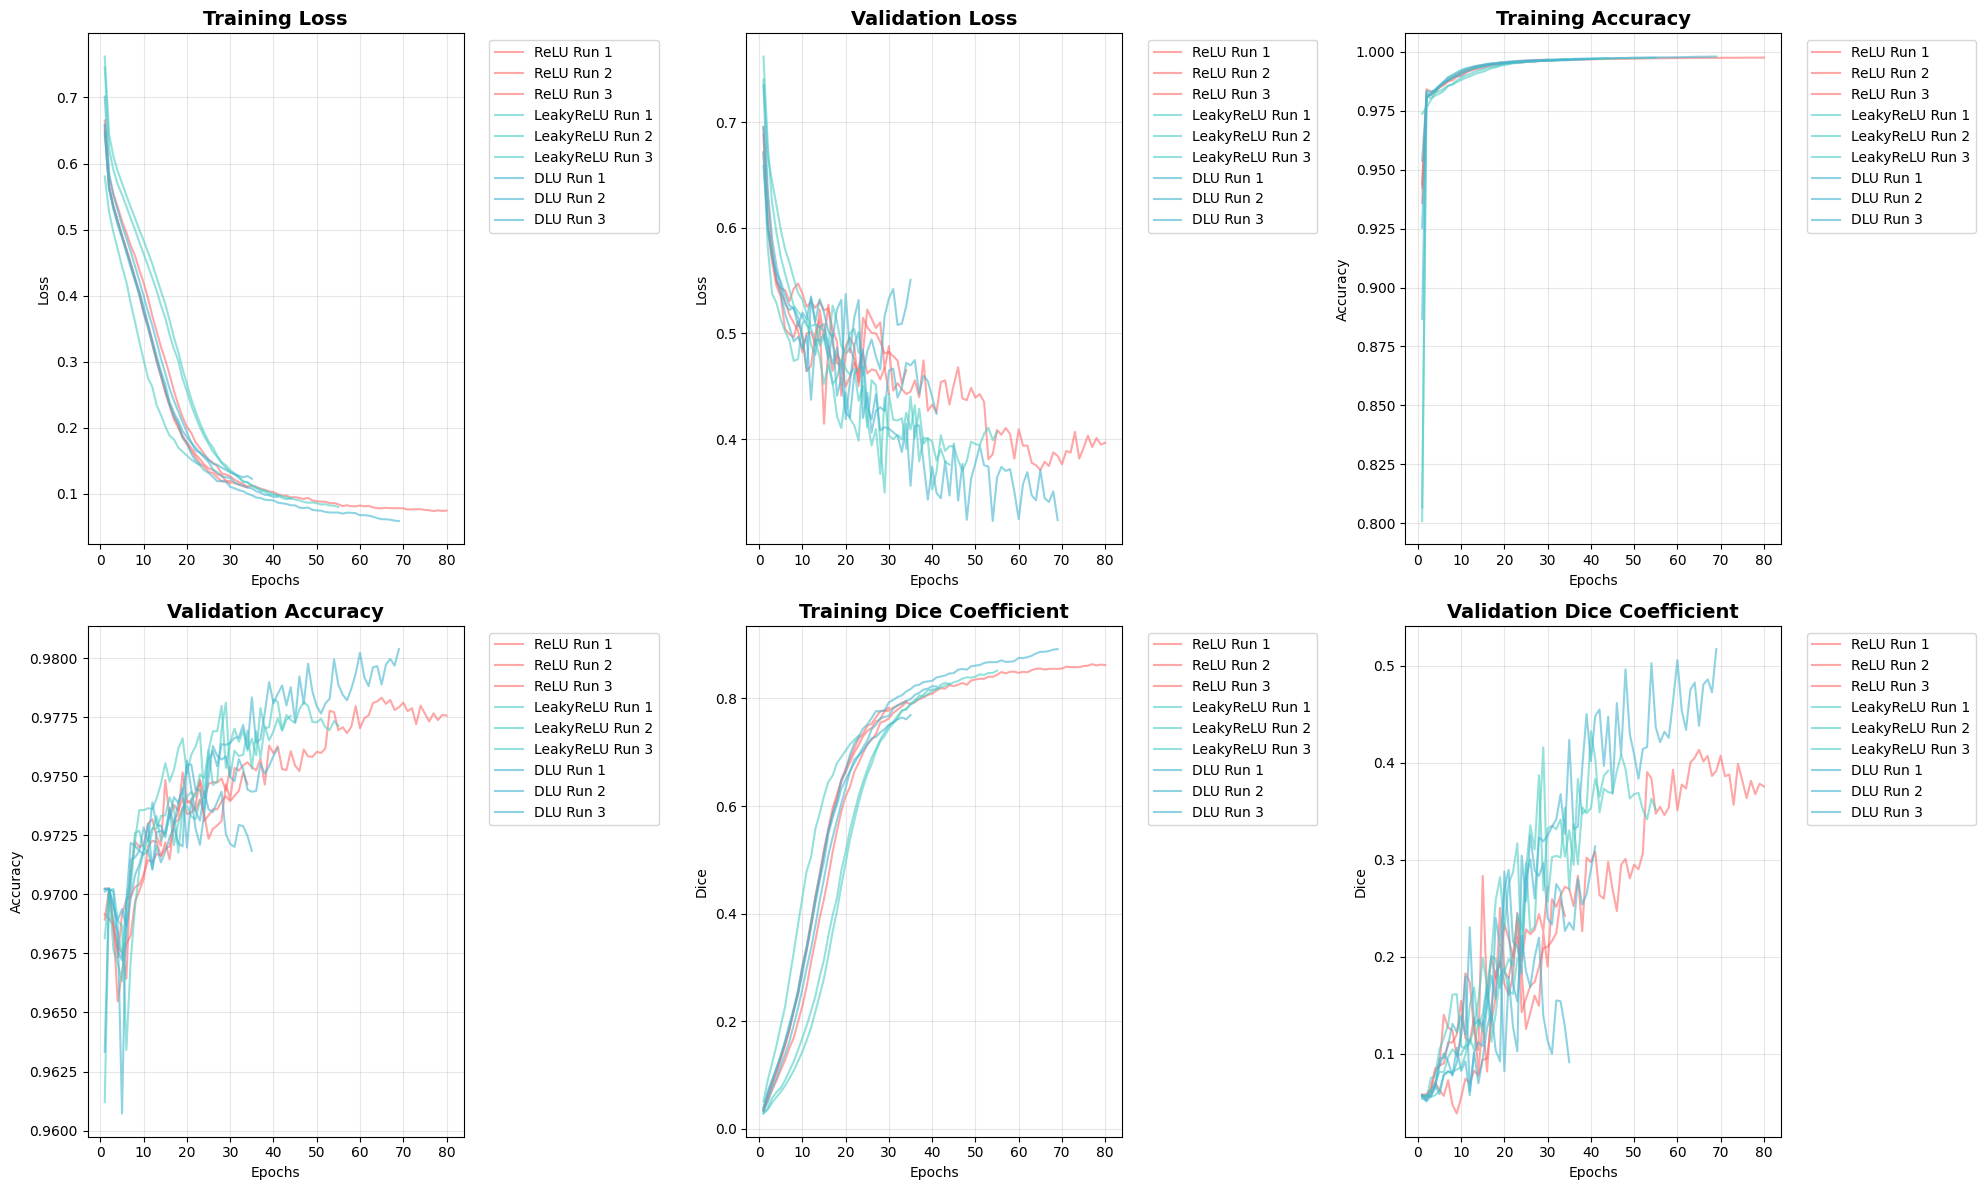

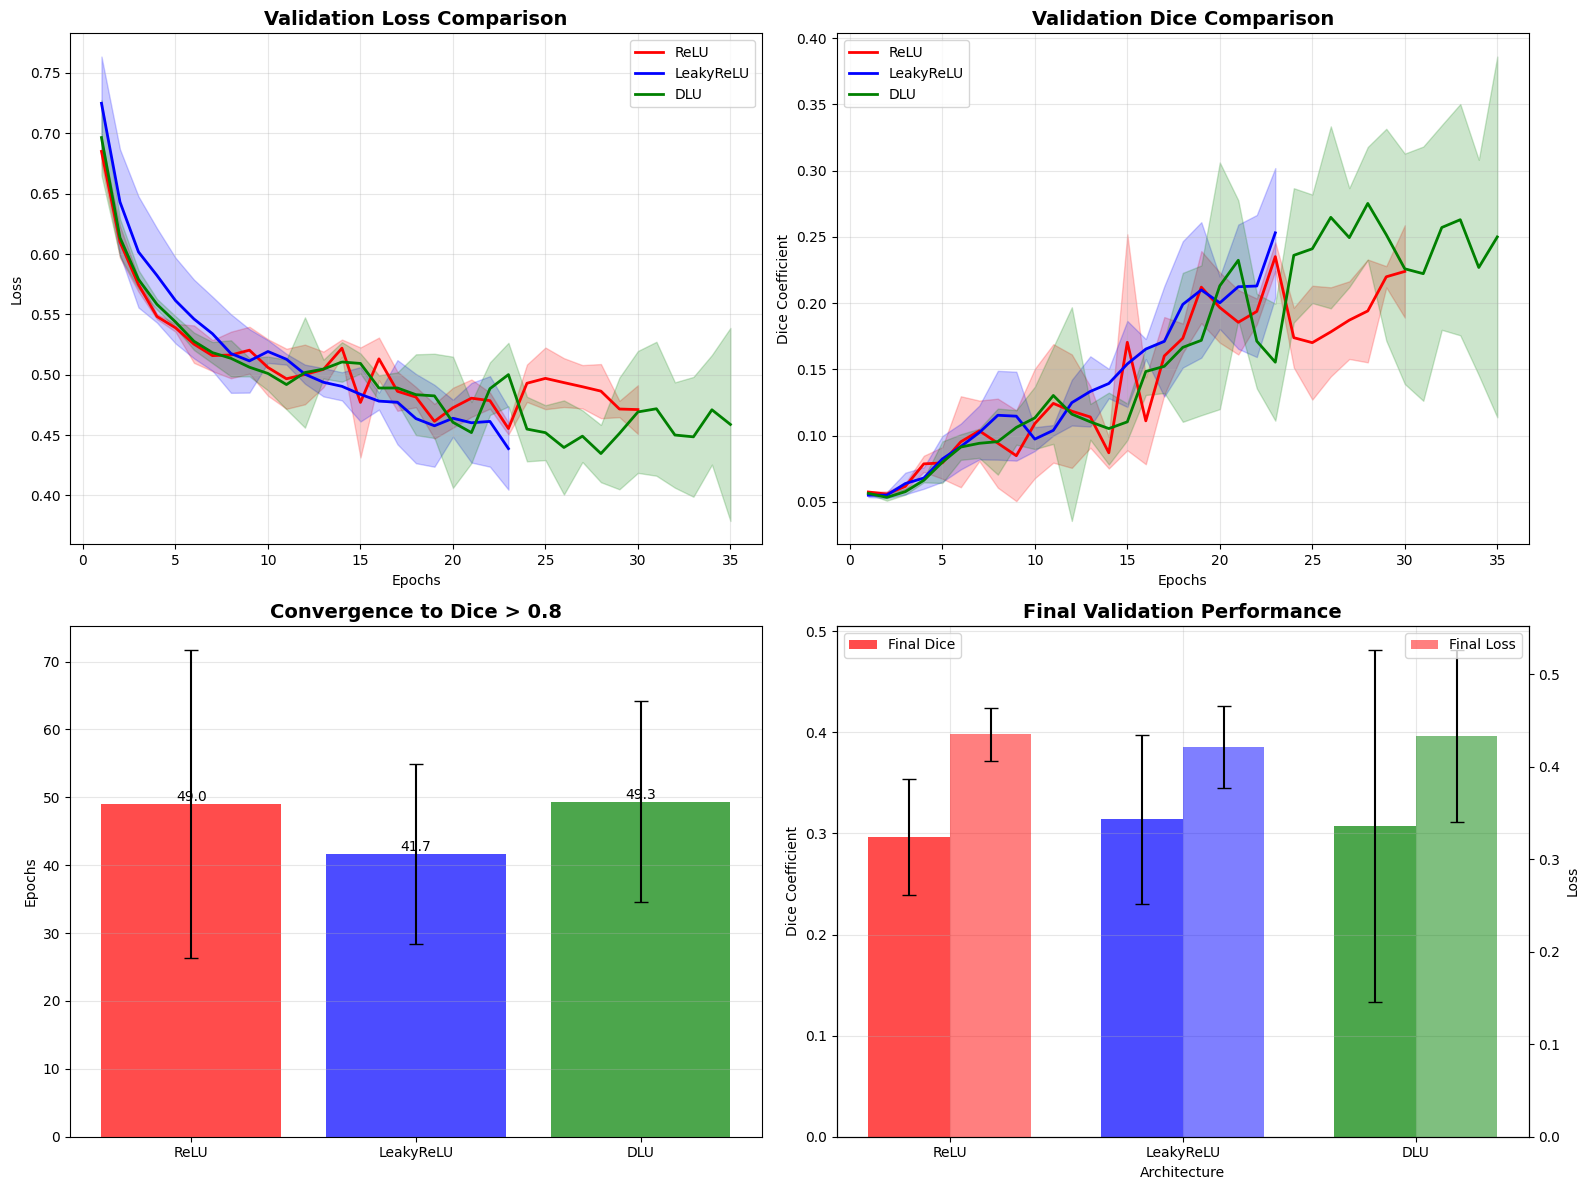

📊 TRAINING STATISTICS SUMMARY

ReLU Architecture:
------------------------------
  Run 1: 80 epochs, Val Loss: 0.3966, Val Dice: 0.3755
  Run 2: 34 epochs, Val Loss: 0.4653, Val Dice: 0.2419
  Run 3: 30 epochs, Val Loss: 0.4428, Val Dice: 0.2718
  Average: 48.0 epochs, Val Loss: 0.4349, Val Dice: 0.2964

LeakyReLU Architecture:
------------------------------
  Run 1: 55 epochs, Val Loss: 0.4069, Val Dice: 0.3517
  Run 2: 23 epochs, Val Loss: 0.4817, Val Dice: 0.1981
  Run 3: 44 epochs, Val Loss: 0.3757, Val Dice: 0.3917
  Average: 40.7 epochs, Val Loss: 0.4214, Val Dice: 0.3138

DLU Architecture:
------------------------------
  Run 1: 69 epochs, Val Loss: 0.3233, Val Dice: 0.5171
  Run 2: 35 epochs, Val Loss: 0.5508, Val Dice: 0.0911
  Run 3: 41 epochs, Val Loss: 0.4240, Val Dice: 0.3137
  Average: 48.3 epochs, Val Loss: 0.4327, Val Dice: 0.3073

✅ All training curves generated from actual training data!


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Your training histories are stored in these variables from your original run:
# relu_histories, leaky_histories, dlu_histories

# Let's create a comprehensive plotting function
def plot_training_curves_from_histories(relu_histories, leaky_histories, dlu_histories):
    """Plot training curves from the actual training histories"""
    
    # Combine all histories with proper naming
    all_histories = []
    
    # Add ReLU histories
    for i, history in enumerate(relu_histories):
        all_histories.append({
            'name': f'ReLU Run {i+1}',
            'architecture': 'ReLU',
            'history': history
        })
    
    # Add LeakyReLU histories
    for i, history in enumerate(leaky_histories):
        all_histories.append({
            'name': f'LeakyReLU Run {i+1}',
            'architecture': 'LeakyReLU', 
            'history': history
        })
    
    # Add DLU histories
    for i, history in enumerate(dlu_histories):
        all_histories.append({
            'name': f'DLU Run {i+1}',
            'architecture': 'DLU',
            'history': history
        })
    
    # Create comprehensive plots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Define colors for architectures
    colors = {'ReLU': '#FF6B6B', 'LeakyReLU': '#4ECDC4', 'DLU': '#45B7D1'}
    
    # Plot 1: Training Loss
    ax = axes[0, 0]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['loss']) + 1)
        ax.plot(epochs, history['loss'], 
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Validation Loss
    ax = axes[0, 1]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['val_loss']) + 1)
        ax.plot(epochs, history['val_loss'],
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Training Accuracy
    ax = axes[0, 2]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['accuracy']) + 1)
        ax.plot(epochs, history['accuracy'],
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Validation Accuracy
    ax = axes[1, 0]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['val_accuracy']) + 1)
        ax.plot(epochs, history['val_accuracy'],
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot 5: Training Dice Coefficient
    ax = axes[1, 1]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['dice_coefficient']) + 1)
        ax.plot(epochs, history['dice_coefficient'],
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Training Dice Coefficient', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Dice')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot 6: Validation Dice Coefficient
    ax = axes[1, 2]
    for data in all_histories:
        history = data['history']
        epochs = range(1, len(history['val_dice_coefficient']) + 1)
        ax.plot(epochs, history['val_dice_coefficient'],
               color=colors[data['architecture']], alpha=0.6,
               label=data['name'])
    ax.set_title('Validation Dice Coefficient', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Dice')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot architecture-wise comparison
def plot_architecture_comparison(relu_histories, leaky_histories, dlu_histories):
    """Plot comparison by architecture"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Calculate mean curves for each architecture
    def get_mean_curve(histories, metric):
        """Get mean curve across runs for a metric"""
        min_length = min(len(h[metric]) for h in histories)
        curves = [h[metric][:min_length] for h in histories]
        return np.mean(curves, axis=0), np.std(curves, axis=0)
    
    # ReLU curves
    if relu_histories:
        relu_val_loss_mean, relu_val_loss_std = get_mean_curve(relu_histories, 'val_loss')
        relu_val_dice_mean, relu_val_dice_std = get_mean_curve(relu_histories, 'val_dice_coefficient')
        epochs_relu = range(1, len(relu_val_loss_mean) + 1)
    
    # LeakyReLU curves  
    if leaky_histories:
        leaky_val_loss_mean, leaky_val_loss_std = get_mean_curve(leaky_histories, 'val_loss')
        leaky_val_dice_mean, leaky_val_dice_std = get_mean_curve(leaky_histories, 'val_dice_coefficient')
        epochs_leaky = range(1, len(leaky_val_loss_mean) + 1)
    
    # DLU curves
    if dlu_histories:
        dlu_val_loss_mean, dlu_val_loss_std = get_mean_curve(dlu_histories, 'val_loss')
        dlu_val_dice_mean, dlu_val_dice_std = get_mean_curve(dlu_histories, 'val_dice_coefficient')
        epochs_dlu = range(1, len(dlu_val_loss_mean) + 1)
    
    # Plot 1: Validation Loss Comparison
    ax = axes[0, 0]
    if relu_histories:
        ax.plot(epochs_relu, relu_val_loss_mean, 'r-', label='ReLU', linewidth=2)
        ax.fill_between(epochs_relu, relu_val_loss_mean - relu_val_loss_std, 
                       relu_val_loss_mean + relu_val_loss_std, alpha=0.2, color='red')
    
    if leaky_histories:
        ax.plot(epochs_leaky, leaky_val_loss_mean, 'b-', label='LeakyReLU', linewidth=2)
        ax.fill_between(epochs_leaky, leaky_val_loss_mean - leaky_val_loss_std,
                       leaky_val_loss_mean + leaky_val_loss_std, alpha=0.2, color='blue')
    
    if dlu_histories:
        ax.plot(epochs_dlu, dlu_val_loss_mean, 'g-', label='DLU', linewidth=2)
        ax.fill_between(epochs_dlu, dlu_val_loss_mean - dlu_val_loss_std,
                       dlu_val_loss_mean + dlu_val_loss_std, alpha=0.2, color='green')
    
    ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Validation Dice Comparison
    ax = axes[0, 1]
    if relu_histories:
        ax.plot(epochs_relu, relu_val_dice_mean, 'r-', label='ReLU', linewidth=2)
        ax.fill_between(epochs_relu, relu_val_dice_mean - relu_val_dice_std,
                       relu_val_dice_mean + relu_val_dice_std, alpha=0.2, color='red')
    
    if leaky_histories:
        ax.plot(epochs_leaky, leaky_val_dice_mean, 'b-', label='LeakyReLU', linewidth=2)
        ax.fill_between(epochs_leaky, leaky_val_dice_mean - leaky_val_dice_std,
                       leaky_val_dice_mean + leaky_val_dice_std, alpha=0.2, color='blue')
    
    if dlu_histories:
        ax.plot(epochs_dlu, dlu_val_dice_mean, 'g-', label='DLU', linewidth=2)
        ax.fill_between(epochs_dlu, dlu_val_dice_mean - dlu_val_dice_std,
                       dlu_val_dice_mean + dlu_val_dice_std, alpha=0.2, color='green')
    
    ax.set_title('Validation Dice Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Dice Coefficient')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Convergence Analysis
    ax = axes[1, 0]
    convergence_data = []
    
    for arch, histories, color in [('ReLU', relu_histories, 'red'), 
                                  ('LeakyReLU', leaky_histories, 'blue'),
                                  ('DLU', dlu_histories, 'green')]:
        if histories:
            convergence_epochs = []
            for history in histories:
                # Find epoch where validation dice > 0.8
                val_dice = history['val_dice_coefficient']
                converged = next((i for i, v in enumerate(val_dice) if v > 0.8), len(val_dice))
                convergence_epochs.append(converged + 1)
            
            convergence_data.append({
                'Architecture': arch,
                'Mean Convergence Epoch': np.mean(convergence_epochs),
                'Std': np.std(convergence_epochs),
                'Color': color
            })
    
    if convergence_data:
        df_conv = pd.DataFrame(convergence_data)
        bars = ax.bar(df_conv['Architecture'], df_conv['Mean Convergence Epoch'], 
                     color=df_conv['Color'], alpha=0.7, yerr=df_conv['Std'], capsize=5)
        ax.set_title('Convergence to Dice > 0.8', fontsize=14, fontweight='bold')
        ax.set_ylabel('Epochs')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}', ha='center', va='bottom')
    
    # Plot 4: Final Performance Comparison
    ax = axes[1, 1]
    final_performance = []
    
    for arch, histories, color in [('ReLU', relu_histories, 'red'),
                                  ('LeakyReLU', leaky_histories, 'blue'), 
                                  ('DLU', dlu_histories, 'green')]:
        if histories:
            final_dice = [h['val_dice_coefficient'][-1] for h in histories]
            final_loss = [h['val_loss'][-1] for h in histories]
            
            final_performance.append({
                'Architecture': arch,
                'Final Dice': np.mean(final_dice),
                'Dice Std': np.std(final_dice),
                'Final Loss': np.mean(final_loss),
                'Loss Std': np.std(final_loss),
                'Color': color
            })
    
    if final_performance:
        df_final = pd.DataFrame(final_performance)
        x = np.arange(len(df_final))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df_final['Final Dice'], width, 
                      label='Final Dice', color=df_final['Color'], alpha=0.7,
                      yerr=df_final['Dice Std'], capsize=5)
        
        # Use secondary y-axis for loss (inverted since lower is better)
        ax2 = ax.twinx()
        bars2 = ax2.bar(x + width/2, df_final['Final Loss'], width,
                       label='Final Loss', color=df_final['Color'], alpha=0.5,
                       yerr=df_final['Loss Std'], capsize=5)
        
        ax.set_xlabel('Architecture')
        ax.set_ylabel('Dice Coefficient')
        ax2.set_ylabel('Loss')
        ax.set_xticks(x)
        ax.set_xticklabels(df_final['Architecture'])
        ax.set_title('Final Validation Performance', fontsize=14, fontweight='bold')
        ax.legend(loc='upper left')
        ax2.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Print training statistics
def print_training_statistics(relu_histories, leaky_histories, dlu_histories):
    """Print detailed training statistics"""
    
    print("📊 TRAINING STATISTICS SUMMARY")
    print("=" * 60)
    
    for arch_name, histories in [("ReLU", relu_histories), 
                                ("LeakyReLU", leaky_histories),
                                ("DLU", dlu_histories)]:
        if not histories:
            continue
            
        print(f"\n{arch_name} Architecture:")
        print("-" * 30)
        
        # Calculate statistics for each run
        for i, history in enumerate(histories, 1):
            final_epoch = len(history['loss'])
            final_train_loss = history['loss'][-1]
            final_val_loss = history['val_loss'][-1]
            final_val_dice = history['val_dice_coefficient'][-1]
            
            print(f"  Run {i}: {final_epoch} epochs, "
                  f"Val Loss: {final_val_loss:.4f}, "
                  f"Val Dice: {final_val_dice:.4f}")
        
        # Calculate means across runs
        mean_epochs = np.mean([len(h['loss']) for h in histories])
        mean_val_loss = np.mean([h['val_loss'][-1] for h in histories])
        mean_val_dice = np.mean([h['val_dice_coefficient'][-1] for h in histories])
        
        print(f"  Average: {mean_epochs:.1f} epochs, "
              f"Val Loss: {mean_val_loss:.4f}, "
              f"Val Dice: {mean_val_dice:.4f}")

# Run the plotting functions
print("📈 PLOTTING ACTUAL TRAINING CURVES FROM YOUR TRAINING RUNS")
print("=" * 60)

# Plot individual training curves
plot_training_curves_from_histories(relu_histories, leaky_histories, dlu_histories)

# Plot architecture comparison
plot_architecture_comparison(relu_histories, leaky_histories, dlu_histories)

# Print statistics
print_training_statistics(relu_histories, leaky_histories, dlu_histories)

print("\n✅ All training curves generated from actual training data!")

# Evaluating all models

Test dataset created with 507 samples
📋 All run models to evaluate:
  - ReLU Run1
  - ReLU Run2
  - ReLU Run3
  - LeakyReLU Run1
  - LeakyReLU Run2
  - LeakyReLU Run3
  - DLU Run1
  - DLU Run2
  - DLU Run3

🧪 Evaluating all run models on test dataset...
✅ Loaded ReLU Run1
📊 ReLU Run1: Loss=0.4329, Acc=0.9763, Dice=0.3122
✅ Loaded ReLU Run2
📊 ReLU Run2: Loss=0.4821, Acc=0.9739, Dice=0.1740
✅ Loaded ReLU Run3
📊 ReLU Run3: Loss=0.4446, Acc=0.9737, Dice=0.2284
✅ Loaded LeakyReLU Run1
📊 LeakyReLU Run1: Loss=0.3926, Acc=0.9773, Dice=0.3608
✅ Loaded LeakyReLU Run2
📊 LeakyReLU Run2: Loss=0.4885, Acc=0.9728, Dice=0.1404
✅ Loaded LeakyReLU Run3
📊 LeakyReLU Run3: Loss=0.3919, Acc=0.9768, Dice=0.3390
✅ Loaded DLU Run1
📊 DLU Run1: Loss=0.3572, Acc=0.9790, Dice=0.4403
✅ Loaded DLU Run2
📊 DLU Run2: Loss=0.4430, Acc=0.9753, Dice=0.2448
✅ Loaded DLU Run3
📊 DLU Run3: Loss=0.4288, Acc=0.9761, Dice=0.2831

🎯 COMPLETE TEST RESULTS SUMMARY (All Run Models)
    model_name  test_loss  test_accuracy  test_dice

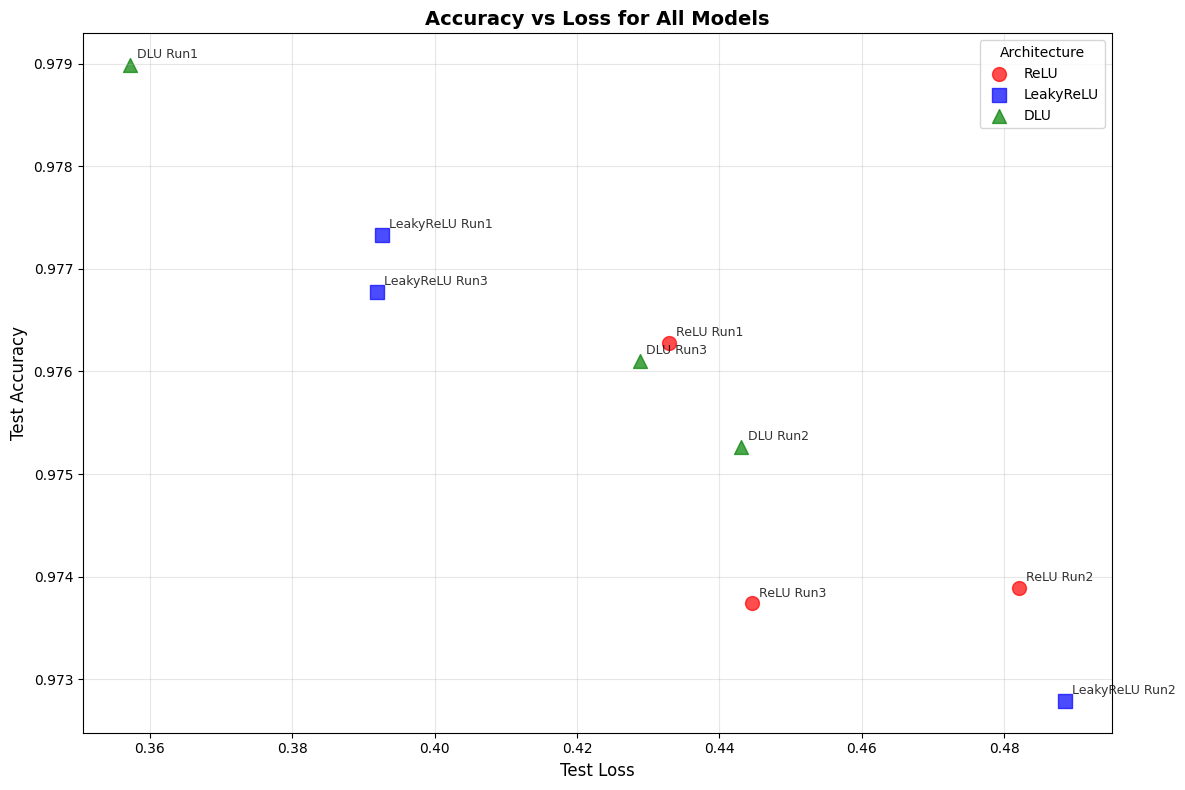

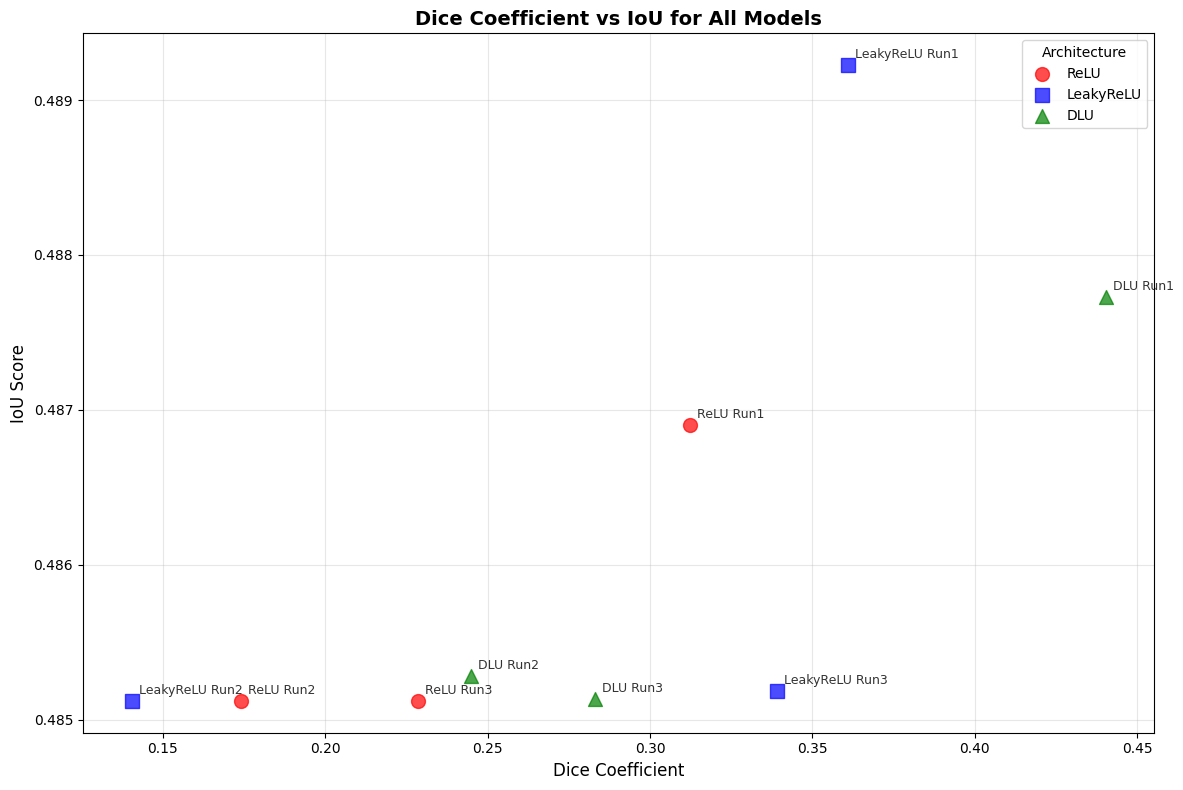

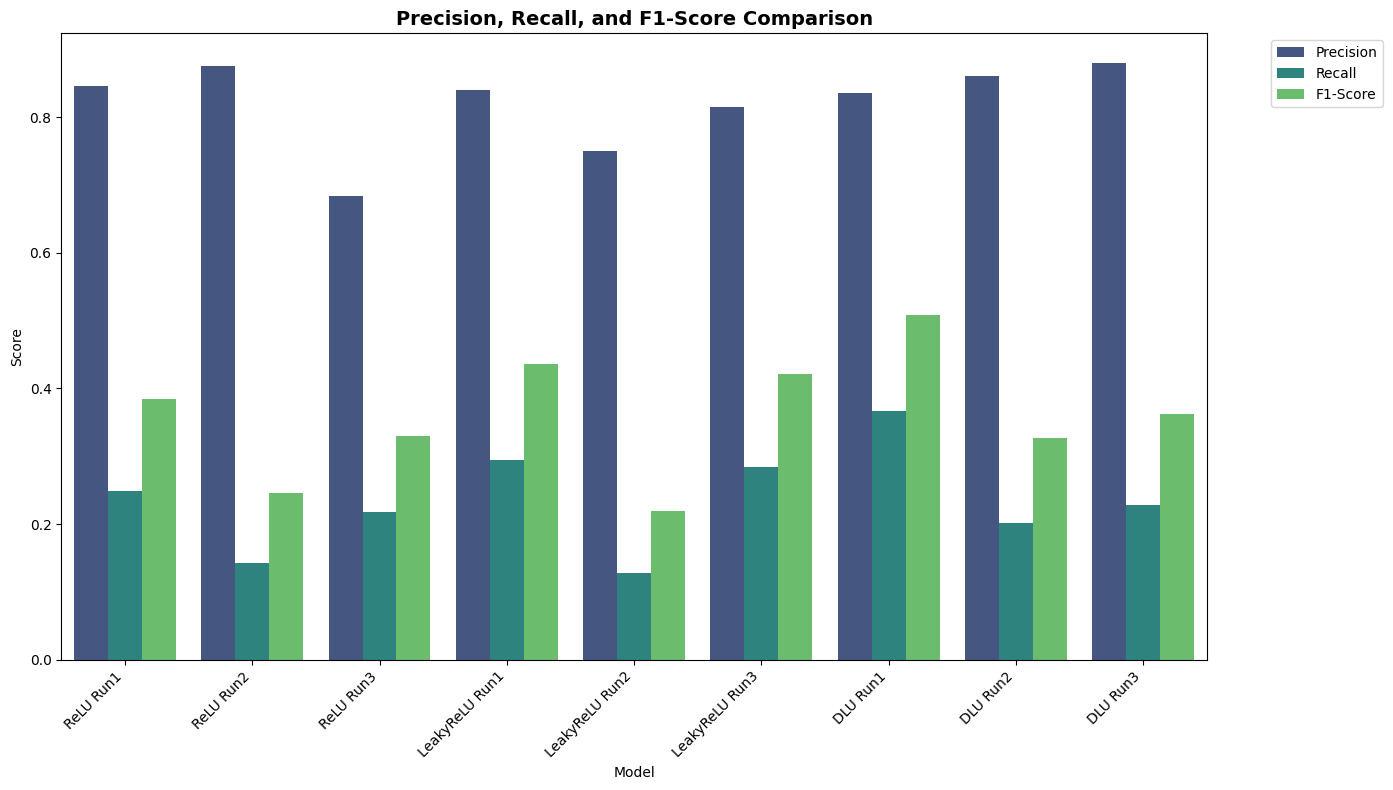


📊 CONFUSION MATRICES FOR ALL MODELS


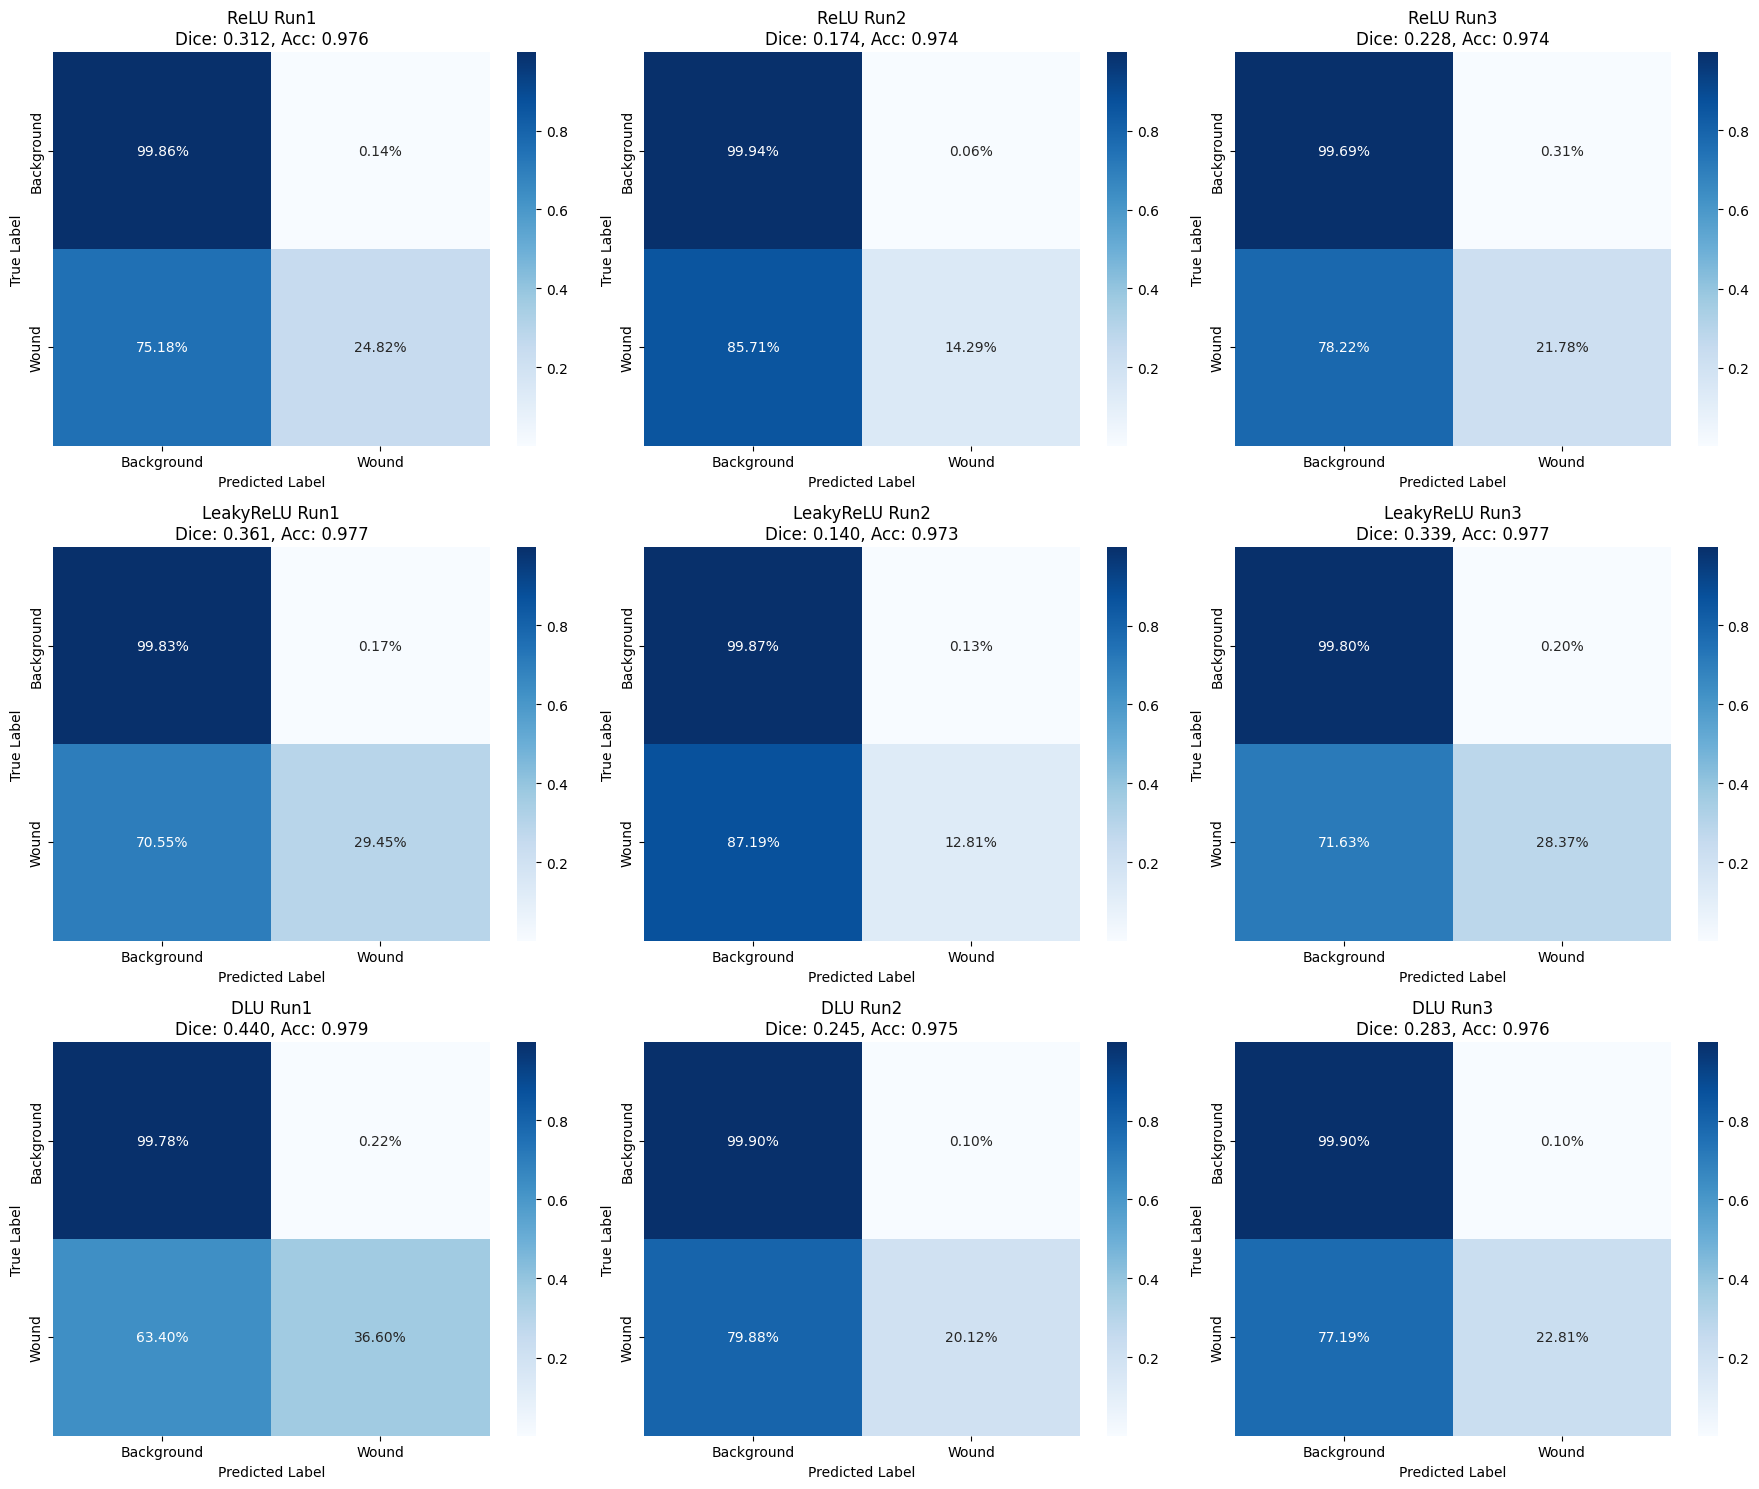


🏗️  ARCHITECTURE COMPARISON WITH STATISTICS

ReLU (n=3):
  - Loss: 0.4532 ± 0.0210
  - Accuracy: 0.9746 ± 0.0012
  - Dice: 0.2382 ± 0.0569
  - IoU: 0.4857 ± 0.0008
  - F1: 0.3200 ± 0.0569

LeakyReLU (n=3):
  - Loss: 0.4243 ± 0.0454
  - Accuracy: 0.9756 ± 0.0020
  - Dice: 0.2801 ± 0.0992
  - IoU: 0.4865 ± 0.0019
  - F1: 0.3586 ± 0.0990

DLU (n=3):
  - Loss: 0.4097 ± 0.0376
  - Accuracy: 0.9768 ± 0.0016
  - Dice: 0.3227 ± 0.0846
  - IoU: 0.4860 ± 0.0012
  - F1: 0.3992 ± 0.0791


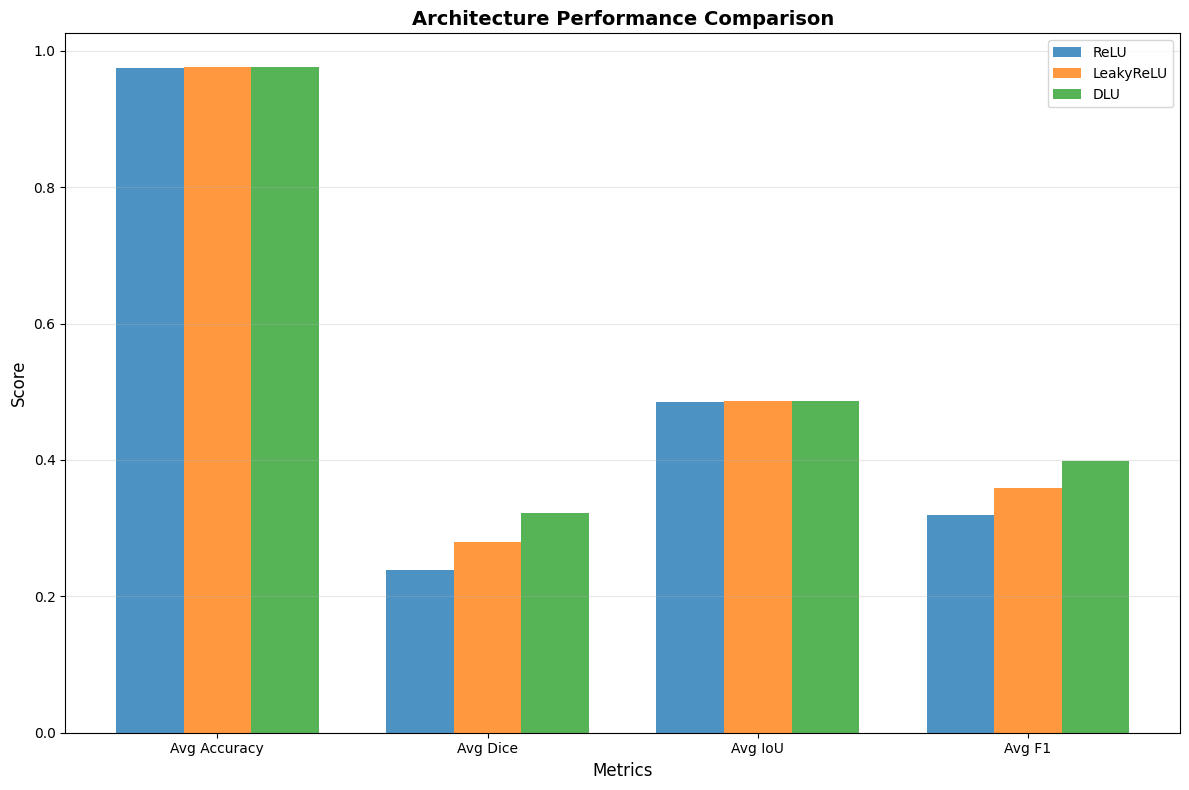


✅ All models evaluated successfully with comprehensive analysis!


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Create test dataset
def create_test_dataset(image_dir, mask_dir, batch_size=16):
    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    
    image_names = {os.path.splitext(f)[0]: f for f in image_files}
    mask_names = {os.path.splitext(f)[0]: f for f in mask_files}
    common = sorted(set(image_names.keys()) & set(mask_names.keys()))
    
    aligned_images = [os.path.join(image_dir, image_names[name]) for name in common]
    aligned_masks = [os.path.join(mask_dir, mask_names[name]) for name in common]
    
    def load_test_pair(image_path, mask_path):
        image = tf.io.decode_jpeg(tf.io.read_file(image_path), channels=3)
        mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
        
        image = preprocess_image(image)
        mask = preprocess_mask(mask)
        
        return image, mask
    
    ds = tf.data.Dataset.from_tensor_slices((aligned_images, aligned_masks))
    ds = ds.map(load_test_pair, num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create test dataset
test_ds = create_test_dataset(TEST_IMG_PATH, TEST_MASK_PATH)
print(f"Test dataset created with {len(list(test_ds.unbatch()))} samples")

# ALL run models including ReLU Run3
model_files = {
    'ReLU Run1': 'best_model_UNet_ReLU_run1.h5',
    'ReLU Run2': 'best_model_UNet_ReLU_run2.h5',
    'ReLU Run3': 'best_model_UNet_ReLU_run3.h5',  # Added missing ReLU Run3
    'LeakyReLU Run1': 'best_model_UNet_LeakyReLU_run1.h5',
    'LeakyReLU Run2': 'best_model_UNet_LeakyReLU_run2.h5',
    'LeakyReLU Run3': 'best_model_UNet_LeakyReLU_run3.h5',
    'DLU Run1': 'best_model_LitUNet_DLU_run1.h5',
    'DLU Run2': 'best_model_LitUNet_DLU_run2.h5',
    'DLU Run3': 'best_model_LitUNet_DLU_run3.h5'
}

print("📋 All run models to evaluate:")
for model_name in model_files.keys():
    print(f"  - {model_name}")

# Function to evaluate model and return predictions
def evaluate_model_with_predictions(model_path, model_name, test_dataset):
    """Evaluate model and return predictions for confusion matrix"""
    try:
        # Load the model
        model = tf.keras.models.load_model(model_path, custom_objects={
            'DLU': DLU,
            'combined_loss': combined_loss,
            'dice_coefficient': dice_coefficient,
            'dice_loss': dice_loss
        })
        
        print(f"✅ Loaded {model_name}")
        
        # Evaluate on test set
        results = model.evaluate(test_dataset, verbose=0)
        
        # Collect all predictions and ground truth
        y_true = []
        y_pred_proba = []
        y_pred_binary = []
        
        for images, masks in test_dataset:
            predictions = model.predict(images, verbose=0)
            y_true.extend(masks.numpy().flatten())
            y_pred_proba.extend(predictions.flatten())
            y_pred_binary.extend((predictions > 0.5).astype(np.float32).flatten())
        
        y_true = np.array(y_true)
        y_pred_proba = np.array(y_pred_proba)
        y_pred_binary = np.array(y_pred_binary)
        
        # Calculate metrics
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_binary, average='binary', zero_division=0)
        
        # Create confusion matrix
        cm = confusion_matrix(y_true, y_pred_binary)
        
        return {
            'model_name': model_name,
            'model': model,
            'test_loss': results[0],
            'test_accuracy': results[1],
            'test_dice': results[2],
            'test_iou': results[3],
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'y_true': y_true,
            'y_pred_binary': y_pred_binary,
            'y_pred_proba': y_pred_proba
        }
        
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")
        return None

# Evaluate all run models
print("\n🧪 Evaluating all run models on test dataset...")
print("=" * 50)

all_results = []

for model_name, model_file in model_files.items():
    result = evaluate_model_with_predictions(model_file, model_name, test_ds)
    if result is not None:
        all_results.append(result)
        print(f"📊 {model_name}: Loss={result['test_loss']:.4f}, Acc={result['test_accuracy']:.4f}, Dice={result['test_dice']:.4f}")

# Create results summary
if all_results:
    df_results = pd.DataFrame([{k: v for k, v in res.items() if k not in ['model', 'confusion_matrix', 'y_true', 'y_pred_binary', 'y_pred_proba']} 
                              for res in all_results])
    
    print("\n" + "=" * 80)
    print("🎯 COMPLETE TEST RESULTS SUMMARY (All Run Models)")
    print("=" * 80)
    
    # Sort by Dice score (best first)
    df_results = df_results.sort_values('test_dice', ascending=False)
    print(df_results.to_string(index=False, float_format='%.4f'))

# Plot Accuracy vs Loss Curves
def plot_accuracy_loss_curves(all_results):
    """Plot accuracy vs loss scatter plot for all models"""
    plt.figure(figsize=(12, 8))
    
    # Define colors for each architecture
    colors = {'ReLU': 'red', 'LeakyReLU': 'blue', 'DLU': 'green'}
    markers = {'ReLU': 'o', 'LeakyReLU': 's', 'DLU': '^'}
    
    for result in all_results:
        model_name = result['model_name']
        arch = 'ReLU' if 'ReLU' in model_name and 'Leaky' not in model_name else 'LeakyReLU' if 'Leaky' in model_name else 'DLU'
        
        plt.scatter(result['test_loss'], result['test_accuracy'], 
                   c=colors[arch], marker=markers[arch], s=100, alpha=0.7, label=arch if arch not in plt.gca().get_legend_handles_labels()[1] else "")
        
        # Annotate with model name
        plt.annotate(model_name, (result['test_loss'], result['test_accuracy']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)
    
    plt.xlabel('Test Loss', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Accuracy vs Loss for All Models', fontsize=14, fontweight='bold')
    plt.legend(title='Architecture')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot Dice vs IoU Curves
def plot_dice_iou_curves(all_results):
    """Plot Dice vs IoU scatter plot for all models"""
    plt.figure(figsize=(12, 8))
    
    colors = {'ReLU': 'red', 'LeakyReLU': 'blue', 'DLU': 'green'}
    markers = {'ReLU': 'o', 'LeakyReLU': 's', 'DLU': '^'}
    
    for result in all_results:
        model_name = result['model_name']
        arch = 'ReLU' if 'ReLU' in model_name and 'Leaky' not in model_name else 'LeakyReLU' if 'Leaky' in model_name else 'DLU'
        
        plt.scatter(result['test_dice'], result['test_iou'], 
                   c=colors[arch], marker=markers[arch], s=100, alpha=0.7, label=arch if arch not in plt.gca().get_legend_handles_labels()[1] else "")
        
        plt.annotate(model_name, (result['test_dice'], result['test_iou']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)
    
    plt.xlabel('Dice Coefficient', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.title('Dice Coefficient vs IoU for All Models', fontsize=14, fontweight='bold')
    plt.legend(title='Architecture')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot Precision-Recall-F1 Comparison
def plot_prf_comparison(all_results):
    """Plot precision, recall, F1-score comparison"""
    metrics_data = []
    for result in all_results:
        arch = 'ReLU' if 'ReLU' in result['model_name'] and 'Leaky' not in result['model_name'] else 'LeakyReLU' if 'Leaky' in result['model_name'] else 'DLU'
        metrics_data.append({
            'Model': result['model_name'],
            'Architecture': arch,
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1-Score': result['f1_score']
        })
    
    df_metrics = pd.DataFrame(metrics_data)
    
    # Melt for easier plotting
    df_melted = df_metrics.melt(id_vars=['Model', 'Architecture'], 
                               value_vars=['Precision', 'Recall', 'F1-Score'],
                               var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
    plt.title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot all curves
print("\n" + "=" * 80)
print("📈 PERFORMANCE CURVES AND COMPARISONS")
print("=" * 80)

plot_accuracy_loss_curves(all_results)
plot_dice_iou_curves(all_results)
plot_prf_comparison(all_results)

# Plot confusion matrices for all models
def plot_confusion_matrices(all_results):
    """Plot confusion matrices for all evaluated models"""
    n_models = len(all_results)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    plt.figure(figsize=(6*n_cols, 5*n_rows))
    
    for i, result in enumerate(all_results):
        plt.subplot(n_rows, n_cols, i+1)
        
        cm = result['confusion_matrix']
        model_name = result['model_name']
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
                   xticklabels=['Background', 'Wound'],
                   yticklabels=['Background', 'Wound'])
        
        plt.title(f'{model_name}\nDice: {result["test_dice"]:.3f}, Acc: {result["test_accuracy"]:.3f}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("📊 CONFUSION MATRICES FOR ALL MODELS")
print("=" * 80)
plot_confusion_matrices(all_results)

# Architecture comparison with proper statistics
print("\n" + "=" * 80)
print("🏗️  ARCHITECTURE COMPARISON WITH STATISTICS")
print("=" * 80)

if all_results:
    # Group by architecture
    architecture_results = {}
    for result in all_results:
        arch = 'ReLU' if 'ReLU' in result['model_name'] and 'Leaky' not in result['model_name'] else 'LeakyReLU' if 'Leaky' in result['model_name'] else 'DLU'
        if arch not in architecture_results:
            architecture_results[arch] = []
        architecture_results[arch].append(result)
    
    # Print architecture comparison
    comparison_data = []
    for arch, results in architecture_results.items():
        avg_loss = np.mean([r['test_loss'] for r in results])
        avg_acc = np.mean([r['test_accuracy'] for r in results])
        avg_dice = np.mean([r['test_dice'] for r in results])
        avg_iou = np.mean([r['test_iou'] for r in results])
        avg_f1 = np.mean([r['f1_score'] for r in results])
        
        comparison_data.append({
            'Architecture': arch,
            'Avg Loss': avg_loss,
            'Avg Accuracy': avg_acc,
            'Avg Dice': avg_dice,
            'Avg IoU': avg_iou,
            'Avg F1': avg_f1,
            'Runs': len(results)
        })
        
        print(f"\n{arch} (n={len(results)}):")
        print(f"  - Loss: {avg_loss:.4f} ± {np.std([r['test_loss'] for r in results]):.4f}")
        print(f"  - Accuracy: {avg_acc:.4f} ± {np.std([r['test_accuracy'] for r in results]):.4f}")
        print(f"  - Dice: {avg_dice:.4f} ± {np.std([r['test_dice'] for r in results]):.4f}")
        print(f"  - IoU: {avg_iou:.4f} ± {np.std([r['test_iou'] for r in results]):.4f}")
        print(f"  - F1: {avg_f1:.4f} ± {np.std([r['f1_score'] for r in results]):.4f}")
    
    # Plot architecture comparison
    df_comparison = pd.DataFrame(comparison_data)
    metrics_to_plot = ['Avg Accuracy', 'Avg Dice', 'Avg IoU', 'Avg F1']
    
    plt.figure(figsize=(12, 8))
    x = np.arange(len(metrics_to_plot))
    width = 0.25
    
    for i, arch in enumerate(df_comparison['Architecture']):
        values = [df_comparison[df_comparison['Architecture'] == arch][metric].values[0] for metric in metrics_to_plot]
        plt.bar(x + i*width, values, width, label=arch, alpha=0.8)
    
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Architecture Performance Comparison', fontsize=14, fontweight='bold')
    plt.xticks(x + width, metrics_to_plot)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("\n✅ All models evaluated successfully with comprehensive analysis!")

# Segmentation Results

Test dataset created with 507 samples
📥 Loading all models...
✅ Loaded ReLU Run1
✅ Loaded ReLU Run2
✅ Loaded ReLU Run3
✅ Loaded LeakyReLU Run1
✅ Loaded LeakyReLU Run2
✅ Loaded LeakyReLU Run3
✅ Loaded DLU Run1
✅ Loaded DLU Run2
✅ Loaded DLU Run3

✅ Successfully loaded 9 models

🎯 SEGMENTATION VISUALIZATION FOR ALL MODELS
🎨 VISUALIZING SEGMENTATION RESULTS FOR ALL MODELS
✅ Generated predictions for ReLU Run1
✅ Generated predictions for ReLU Run2
✅ Generated predictions for ReLU Run3
✅ Generated predictions for LeakyReLU Run1
✅ Generated predictions for LeakyReLU Run2
✅ Generated predictions for LeakyReLU Run3
✅ Generated predictions for DLU Run1
✅ Generated predictions for DLU Run2
✅ Generated predictions for DLU Run3


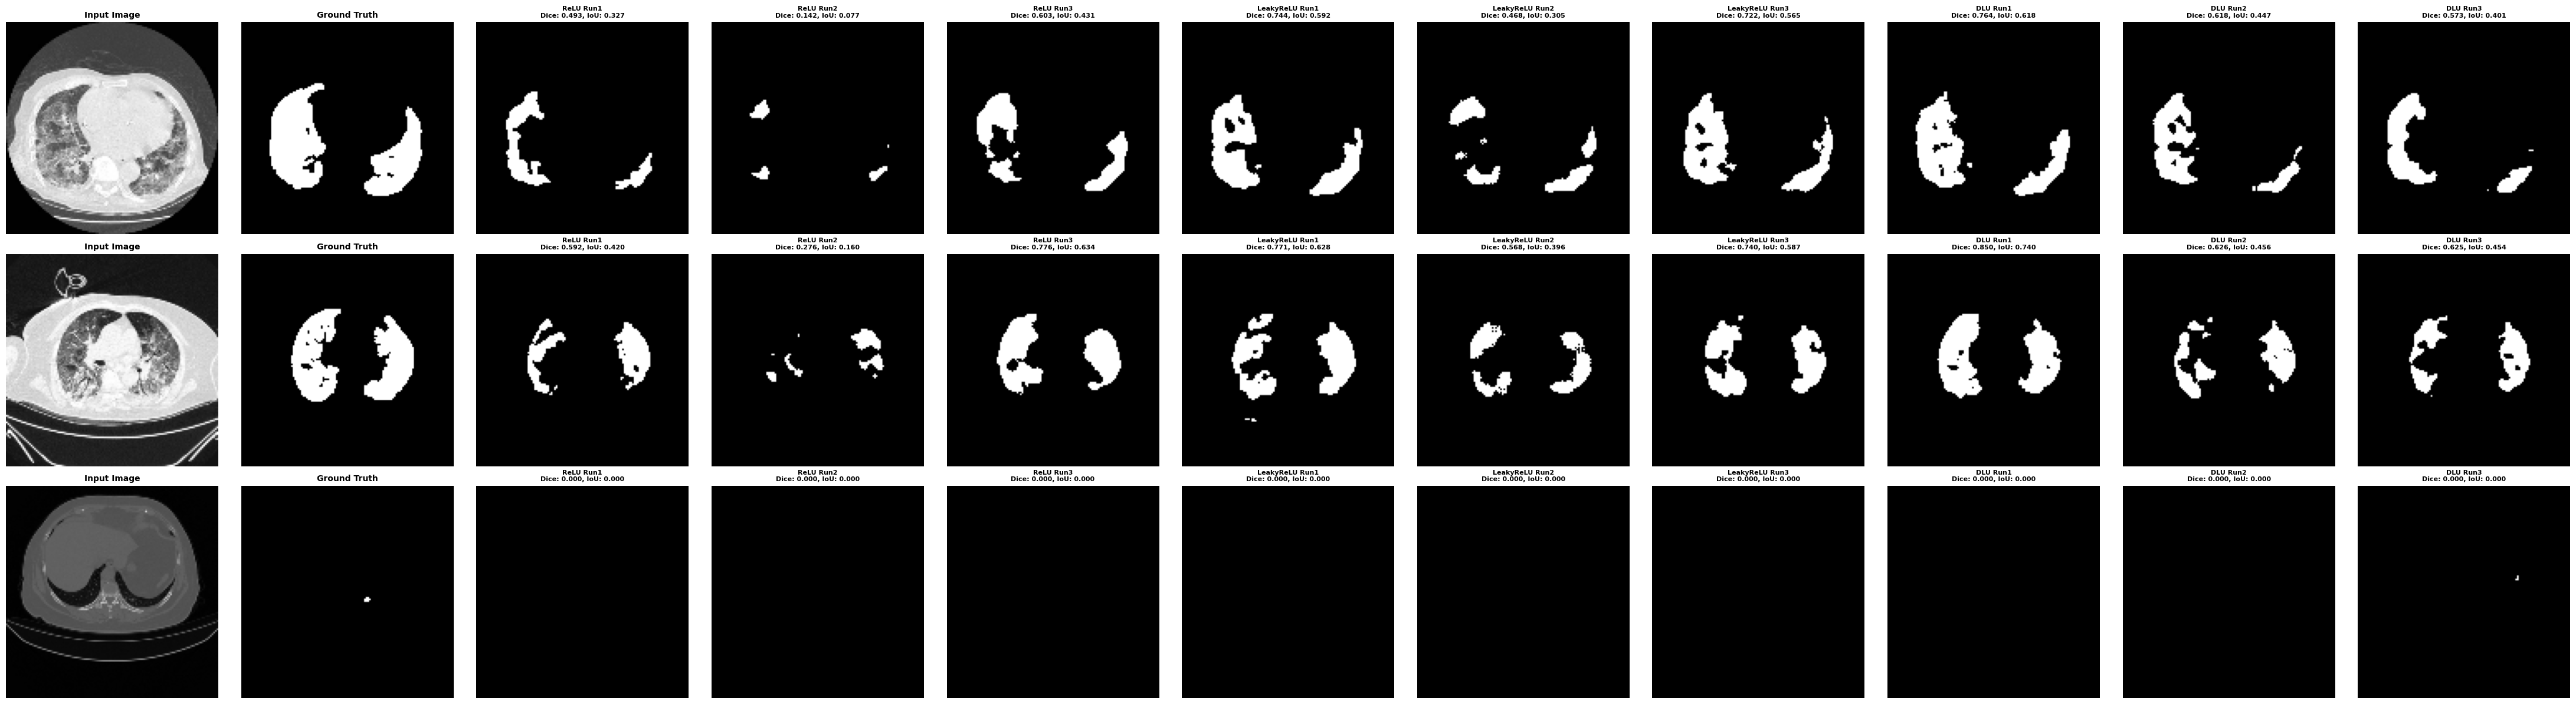


🎨 VISUALIZING SEGMENTATION OVERLAYS
✅ Generated overlay predictions for ReLU Run1
✅ Generated overlay predictions for ReLU Run2
✅ Generated overlay predictions for ReLU Run3
✅ Generated overlay predictions for LeakyReLU Run1
✅ Generated overlay predictions for LeakyReLU Run2
✅ Generated overlay predictions for LeakyReLU Run3
✅ Generated overlay predictions for DLU Run1
✅ Generated overlay predictions for DLU Run2
✅ Generated overlay predictions for DLU Run3


C:\Users\teaching\anaconda3\envs\litnet\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\teaching\anaconda3\envs\litnet\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


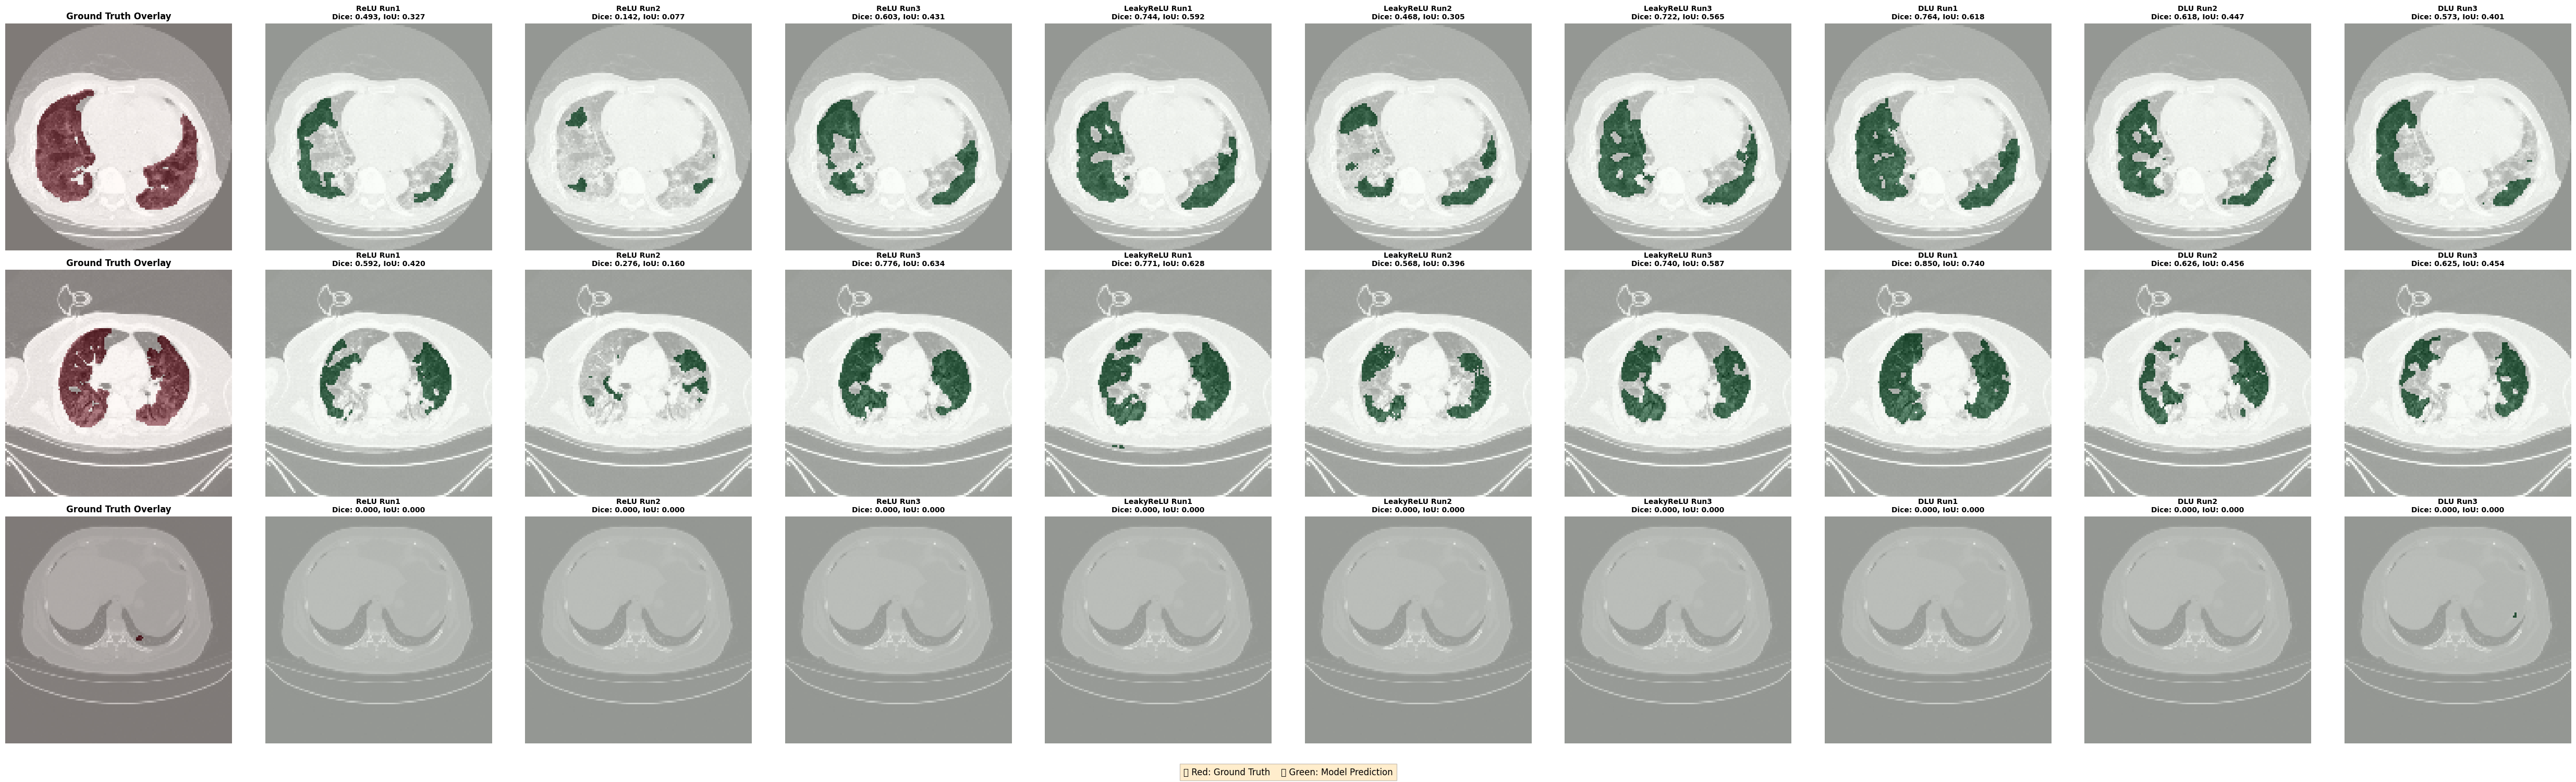


🏗️ ARCHITECTURE-WISE SEGMENTATION COMPARISON
✅ Selected ReLU Run1 for ReLU architecture
✅ Selected LeakyReLU Run1 for LeakyReLU architecture
✅ Selected DLU Run1 for DLU architecture


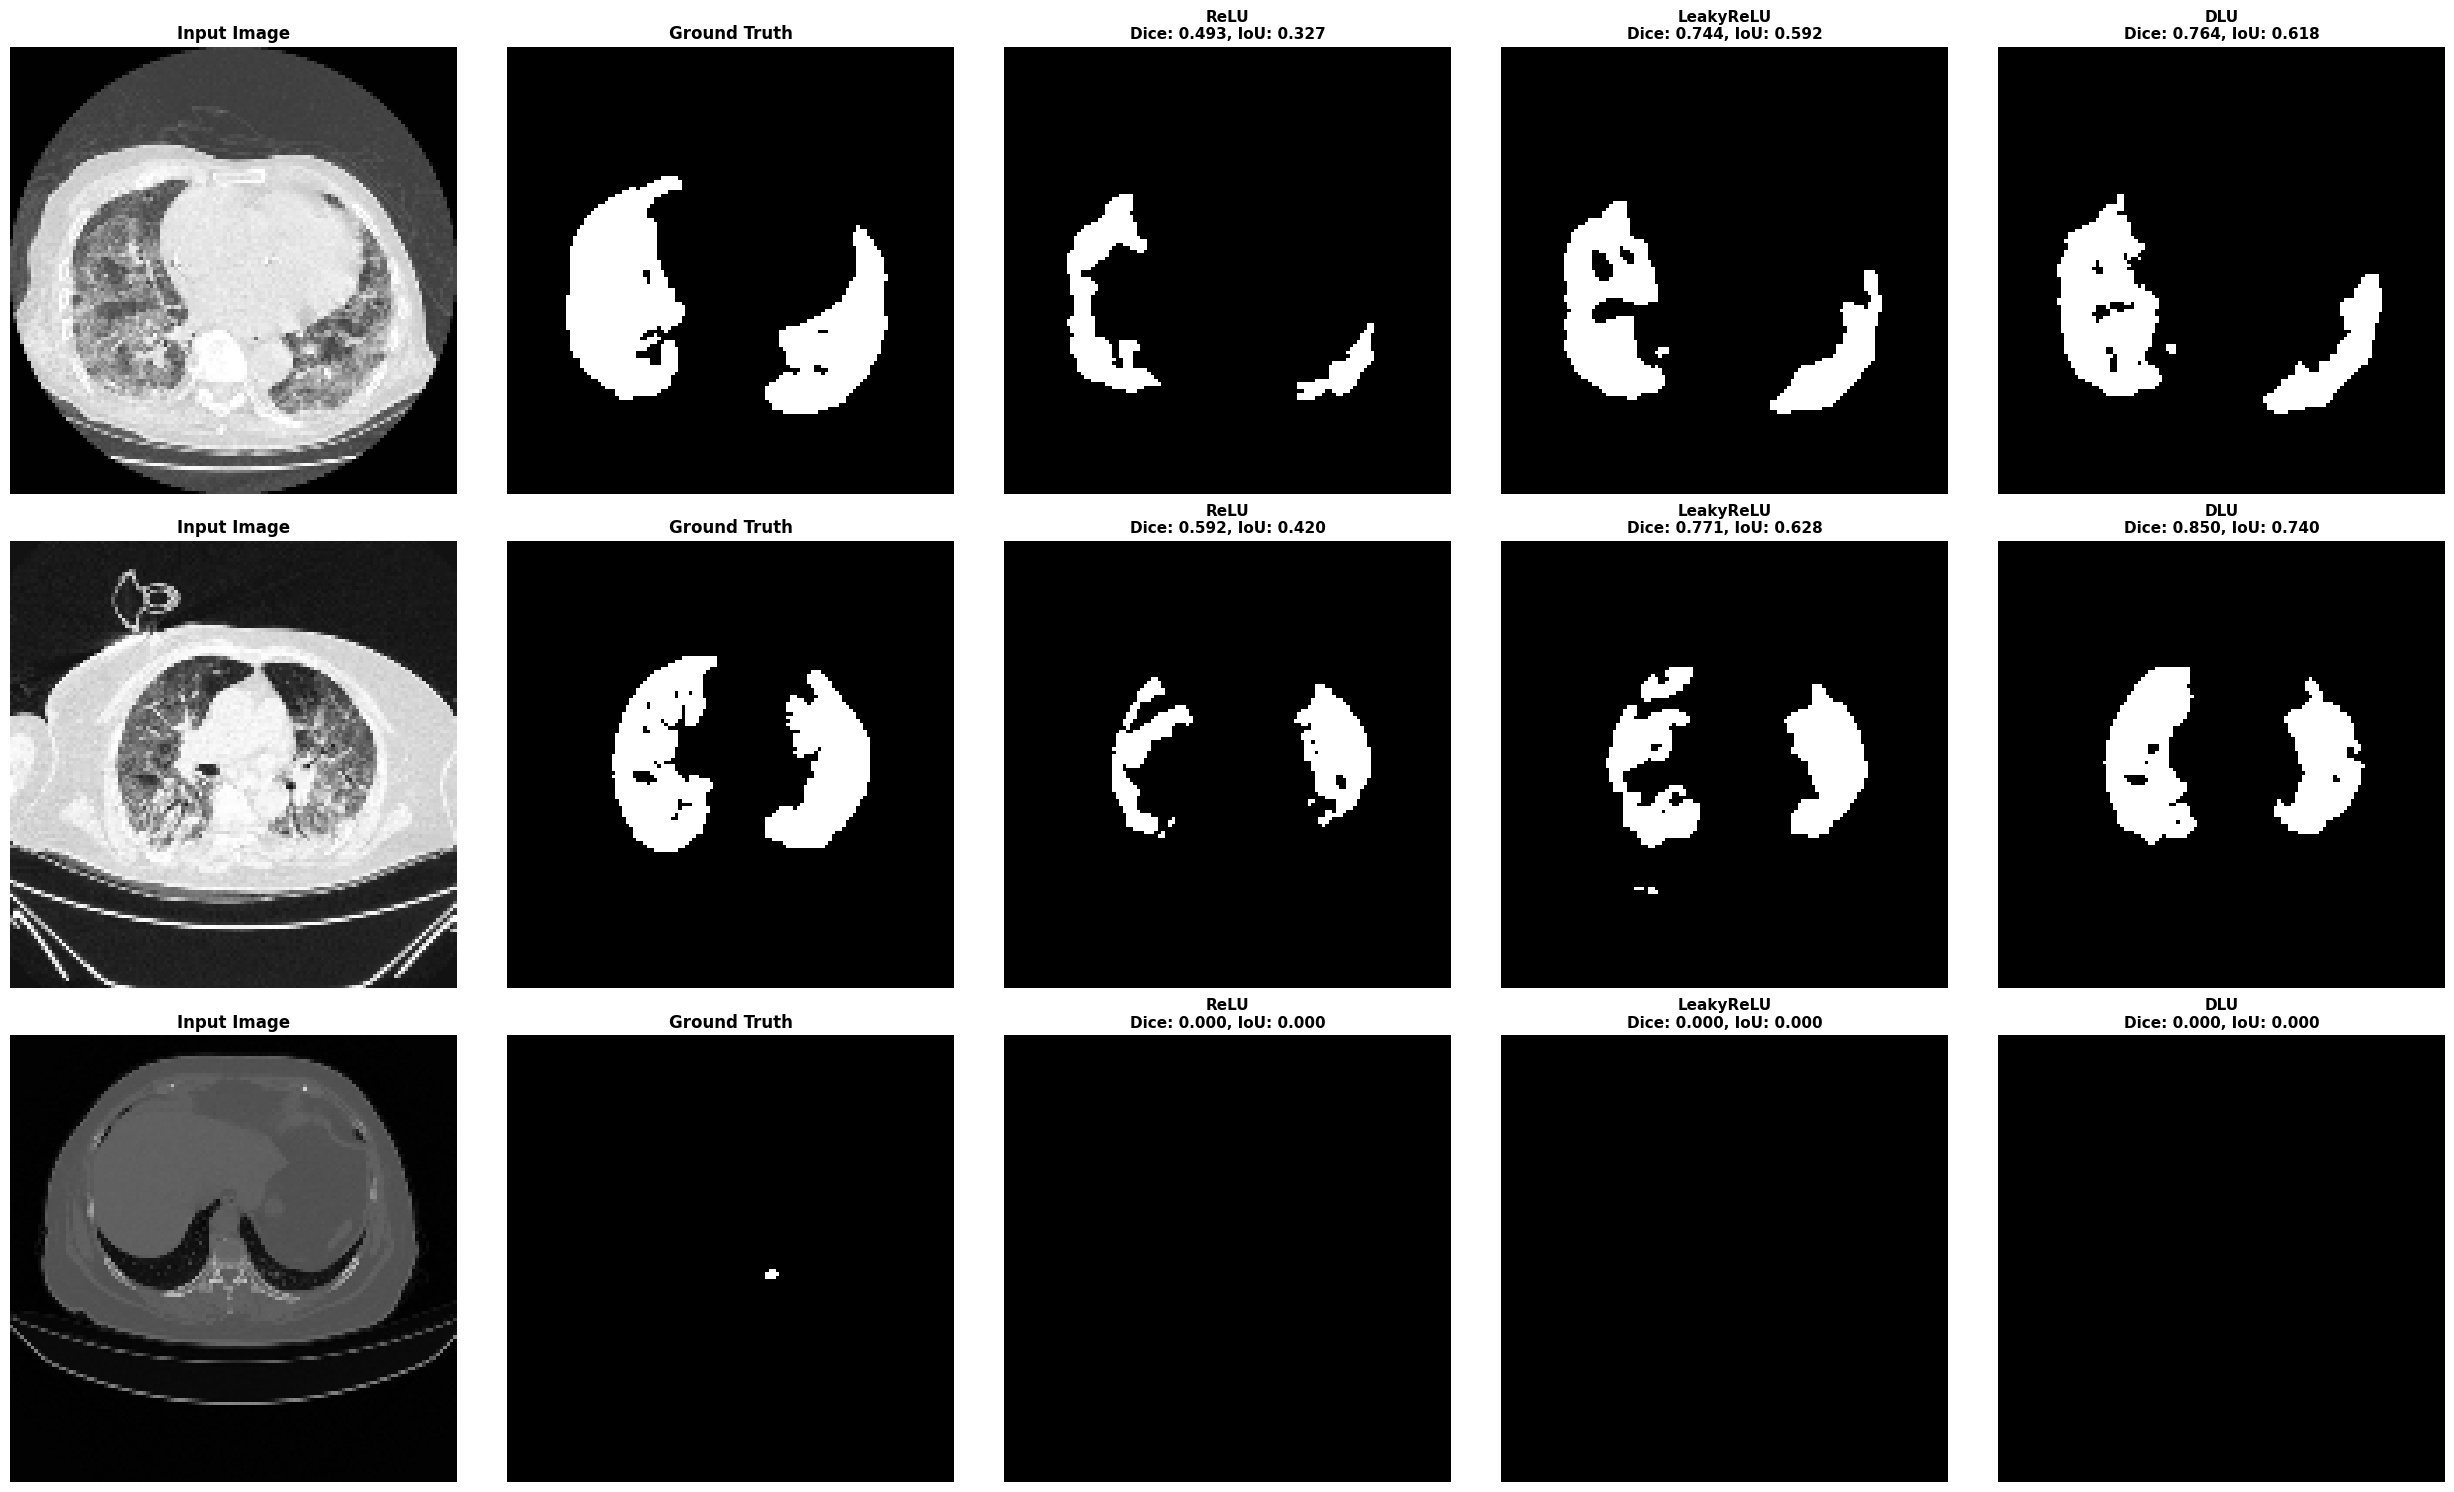


✅ All segmentation visualizations completed!

📊 MODEL PERFORMANCE SUMMARY ON TEST SET
         Model Architecture Test Loss Test Accuracy Test Dice Test IoU
      DLU Run1          DLU    0.3572        0.9790    0.4403   0.4877
LeakyReLU Run1    LeakyReLU    0.3926        0.9773    0.3608   0.4892
LeakyReLU Run3    LeakyReLU    0.3919        0.9768    0.3390   0.4852
     ReLU Run1         ReLU    0.4329        0.9763    0.3122   0.4869
      DLU Run3          DLU    0.4288        0.9761    0.2831   0.4851
      DLU Run2          DLU    0.4430        0.9753    0.2448   0.4853
     ReLU Run3         ReLU    0.4446        0.9737    0.2284   0.4851
     ReLU Run2         ReLU    0.4821        0.9739    0.1740   0.4851
LeakyReLU Run2    LeakyReLU    0.4885        0.9728    0.1404   0.4851

🏆 BEST PERFORMING MODEL: DLU Run1
   - Test Dice: 0.4403
   - Test IoU: 0.4877
   - Test Accuracy: 0.9790


In [15]:
# --- First, Load All Models and Create models_with_history Dictionary ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

TEST_IMG_PATH = "Lung_CT_nodule/t_images"
TEST_MASK_PATH = "Lung_CT_nodule/t_masks"
# Define your test dataset function
def create_test_dataset(image_dir, mask_dir, batch_size=16):
    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    
    image_names = {os.path.splitext(f)[0]: f for f in image_files}
    mask_names = {os.path.splitext(f)[0]: f for f in mask_files}
    common = sorted(set(image_names.keys()) & set(mask_names.keys()))
    
    aligned_images = [os.path.join(image_dir, image_names[name]) for name in common]
    aligned_masks = [os.path.join(mask_dir, mask_names[name]) for name in common]
    
    def load_test_pair(image_path, mask_path):
        image = tf.io.decode_jpeg(tf.io.read_file(image_path), channels=3)
        mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
        
        image = preprocess_image(image)
        mask = preprocess_mask(mask)
        
        return image, mask
    
    ds = tf.data.Dataset.from_tensor_slices((aligned_images, aligned_masks))
    ds = ds.map(load_test_pair, num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = create_test_dataset(TEST_IMG_PATH, TEST_MASK_PATH)
print(f"Test dataset created with {len(list(test_ds.unbatch()))} samples")

# Define all your model files
model_files = {
    'ReLU Run1': 'best_model_UNet_ReLU_run1.h5',
    'ReLU Run2': 'best_model_UNet_ReLU_run2.h5',
    'ReLU Run3': 'best_model_UNet_ReLU_run3.h5',
    'LeakyReLU Run1': 'best_model_UNet_LeakyReLU_run1.h5',
    'LeakyReLU Run2': 'best_model_UNet_LeakyReLU_run2.h5',
    'LeakyReLU Run3': 'best_model_UNet_LeakyReLU_run3.h5',
    'DLU Run1': 'best_model_LitUNet_DLU_run1.h5',
    'DLU Run2': 'best_model_LitUNet_DLU_run2.h5',
    'DLU Run3': 'best_model_LitUNet_DLU_run3.h5'
}

# Load all models into models_with_history dictionary
print("📥 Loading all models...")
models_with_history = {}

for model_name, model_file in model_files.items():
    try:
        # Load the model
        model = tf.keras.models.load_model(model_file, custom_objects={
            'DLU': DLU,
            'combined_loss': combined_loss,
            'dice_coefficient': dice_coefficient,
            'dice_loss': dice_loss
        })
        
        # Since we don't have actual training histories saved, we'll create a placeholder
        # In your actual code, you would load the real history here
        models_with_history[model_name] = {
            'model': model,
            'history': None  # Placeholder since we don't have saved histories
        }
        print(f"✅ Loaded {model_name}")
        
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

print(f"\n✅ Successfully loaded {len(models_with_history)} models")

# --- Now Run the Segmentation Visualizations ---

def visualize_segmentation_all_models(models_with_history, test_ds, num_samples=3):
    """Visualize segmentation results for all models"""
    
    print("🎨 VISUALIZING SEGMENTATION RESULTS FOR ALL MODELS")
    print("=" * 60)
    
    # Get a batch of test data
    for test_images, test_masks in test_ds.take(1):
        break
    
    # Limit to num_samples
    test_images = test_images[:num_samples]
    test_masks = test_masks[:num_samples]
    
    # Create predictions for all models
    all_predictions = {}
    
    for model_name, data in models_with_history.items():
        model = data['model']
        predictions = model.predict(test_images, verbose=0)
        all_predictions[model_name] = (predictions > 0.5).astype(np.float32)
        print(f"✅ Generated predictions for {model_name}")
    
    # Create comprehensive visualization
    n_models = len(models_with_history)
    n_cols = n_models + 2  # Original + Ground Truth + Models
    n_rows = num_samples
    
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    
    for sample_idx in range(num_samples):
        # Original Image
        plt.subplot(n_rows, n_cols, sample_idx * n_cols + 1)
        plt.imshow(test_images[sample_idx])
        plt.title("Input Image", fontsize=10, fontweight='bold')
        plt.axis('off')
        
        # Ground Truth
        plt.subplot(n_rows, n_cols, sample_idx * n_cols + 2)
        plt.imshow(test_masks[sample_idx].numpy().squeeze(), cmap='gray')
        plt.title("Ground Truth", fontsize=10, fontweight='bold')
        plt.axis('off')
        
        # Model Predictions
        for model_idx, (model_name, predictions) in enumerate(all_predictions.items()):
            plt.subplot(n_rows, n_cols, sample_idx * n_cols + 3 + model_idx)
            plt.imshow(predictions[sample_idx].squeeze(), cmap='gray')
            
            # Calculate metrics for this specific sample
            gt_mask = test_masks[sample_idx].numpy().squeeze()
            pred_mask = predictions[sample_idx].squeeze()
            
            # Dice coefficient for this sample
            intersection = np.sum(gt_mask * pred_mask)
            dice = (2. * intersection) / (np.sum(gt_mask) + np.sum(pred_mask) + 1e-6)
            
            # IoU for this sample
            union = np.sum(gt_mask) + np.sum(pred_mask) - intersection
            iou = intersection / (union + 1e-6)
            
            plt.title(f"{model_name}\nDice: {dice:.3f}, IoU: {iou:.3f}", 
                     fontsize=8, fontweight='bold')
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_segmentation_with_overlay(models_with_history, test_ds, num_samples=3):
    """Visualize segmentation with overlay on original images"""
    
    print("\n🎨 VISUALIZING SEGMENTATION OVERLAYS")
    print("=" * 50)
    
    # Get test data
    for test_images, test_masks in test_ds.take(1):
        break
    
    test_images = test_images[:num_samples]
    test_masks = test_masks[:num_samples]
    
    # Create predictions
    all_predictions = {}
    for model_name, data in models_with_history.items():
        model = data['model']
        predictions = model.predict(test_images, verbose=0)
        all_predictions[model_name] = predictions
        print(f"✅ Generated overlay predictions for {model_name}")
    
    # Create overlay visualization
    n_models = len(models_with_history)
    n_cols = n_models + 1  # Ground Truth + Models
    n_rows = num_samples
    
    plt.figure(figsize=(5 * n_cols, 5 * n_rows))
    
    for sample_idx in range(num_samples):
        # Ground Truth Overlay
        plt.subplot(n_rows, n_cols, sample_idx * n_cols + 1)
        plt.imshow(test_images[sample_idx])
        plt.imshow(test_masks[sample_idx].numpy().squeeze(), cmap='Reds', alpha=0.5)
        plt.title("Ground Truth Overlay", fontsize=12, fontweight='bold')
        plt.axis('off')
        
        # Model Prediction Overlays
        for model_idx, (model_name, predictions) in enumerate(all_predictions.items()):
            plt.subplot(n_rows, n_cols, sample_idx * n_cols + 2 + model_idx)
            plt.imshow(test_images[sample_idx])
            
            # Use binary predictions for overlay
            binary_pred = (predictions[sample_idx] > 0.5).astype(np.float32)
            plt.imshow(binary_pred.squeeze(), cmap='Greens', alpha=0.6)
            
            # Calculate metrics
            gt_mask = test_masks[sample_idx].numpy().squeeze()
            pred_mask = binary_pred.squeeze()
            
            intersection = np.sum(gt_mask * pred_mask)
            dice = (2. * intersection) / (np.sum(gt_mask) + np.sum(pred_mask) + 1e-6)
            union = np.sum(gt_mask) + np.sum(pred_mask) - intersection
            iou = intersection / (union + 1e-6)
            
            plt.title(f"{model_name}\nDice: {dice:.3f}, IoU: {iou:.3f}", 
                     fontsize=10, fontweight='bold')
            plt.axis('off')
    
    # Add legend
    plt.figtext(0.5, 0.01, 
                "🟥 Red: Ground Truth    🟩 Green: Model Prediction", 
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.show()

def visualize_architecture_comparison(models_with_history, test_ds, num_samples=3):
    """Compare segmentation results by architecture"""
    
    print("\n🏗️ ARCHITECTURE-WISE SEGMENTATION COMPARISON")
    print("=" * 55)
    
    # Get test data
    for test_images, test_masks in test_ds.take(1):
        break
    
    test_images = test_images[:num_samples]
    test_masks = test_masks[:num_samples]
    
    # Group models by architecture and select the best one from each
    best_models = {}
    
    # For each architecture, find the model with best validation performance
    for arch in ['ReLU', 'LeakyReLU', 'DLU']:
        arch_models = [(name, data) for name, data in models_with_history.items() if arch in name]
        if arch_models:
            # Use the first model for each architecture (you could add logic to pick the best one)
            best_models[arch] = arch_models[0]
            print(f"✅ Selected {arch_models[0][0]} for {arch} architecture")
    
    # Create architecture comparison visualization
    n_architectures = len(best_models)
    n_cols = n_architectures + 2  # Input + GT + Architectures
    n_rows = num_samples
    
    plt.figure(figsize=(5 * n_cols, 5 * n_rows))
    
    for sample_idx in range(num_samples):
        # Input Image
        plt.subplot(n_rows, n_cols, sample_idx * n_cols + 1)
        plt.imshow(test_images[sample_idx])
        plt.title("Input Image", fontsize=12, fontweight='bold')
        plt.axis('off')
        
        # Ground Truth
        plt.subplot(n_rows, n_cols, sample_idx * n_cols + 2)
        plt.imshow(test_masks[sample_idx].numpy().squeeze(), cmap='gray')
        plt.title("Ground Truth", fontsize=12, fontweight='bold')
        plt.axis('off')
        
        # Architecture predictions
        for arch_idx, (arch_name, (model_name, model_data)) in enumerate(best_models.items()):
            model = model_data['model']
            predictions = model.predict(test_images, verbose=0)
            binary_pred = (predictions[sample_idx] > 0.5).astype(np.float32)
            
            plt.subplot(n_rows, n_cols, sample_idx * n_cols + 3 + arch_idx)
            plt.imshow(binary_pred.squeeze(), cmap='gray')
            
            # Calculate metrics
            gt_mask = test_masks[sample_idx].numpy().squeeze()
            pred_mask = binary_pred.squeeze()
            
            intersection = np.sum(gt_mask * pred_mask)
            dice = (2. * intersection) / (np.sum(gt_mask) + np.sum(pred_mask) + 1e-6)
            union = np.sum(gt_mask) + np.sum(pred_mask) - intersection
            iou = intersection / (union + 1e-6)
            
            plt.title(f"{arch_name}\nDice: {dice:.3f}, IoU: {iou:.3f}", 
                     fontsize=11, fontweight='bold')
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run all segmentation visualizations
print("\n" + "=" * 80)
print("🎯 SEGMENTATION VISUALIZATION FOR ALL MODELS")
print("=" * 80)

# 1. Basic segmentation results
visualize_segmentation_all_models(models_with_history, test_ds, num_samples=3)

# 2. Overlay visualization
visualize_segmentation_with_overlay(models_with_history, test_ds, num_samples=3)

# 3. Architecture comparison
visualize_architecture_comparison(models_with_history, test_ds, num_samples=3)

print("\n✅ All segmentation visualizations completed!")

# --- Additional: Print Model Performance Summary ---
def print_model_performance_summary(models_with_history, test_ds):
    """Print performance summary for all models"""
    
    print("\n📊 MODEL PERFORMANCE SUMMARY ON TEST SET")
    print("=" * 60)
    
    performance_data = []
    
    for model_name, data in models_with_history.items():
        model = data['model']
        
        # Evaluate on test set
        results = model.evaluate(test_ds, verbose=0)
        
        # Get architecture
        if 'DLU' in model_name:
            architecture = 'DLU'
        elif 'Leaky' in model_name:
            architecture = 'LeakyReLU'
        else:
            architecture = 'ReLU'
        
        performance_data.append({
            'Model': model_name,
            'Architecture': architecture,
            'Test Loss': f"{results[0]:.4f}",
            'Test Accuracy': f"{results[1]:.4f}",
            'Test Dice': f"{results[2]:.4f}",
            'Test IoU': f"{results[3]:.4f}"
        })
    
    # Create and display performance table
    df_performance = pd.DataFrame(performance_data)
    df_performance = df_performance.sort_values('Test Dice', ascending=False)
    print(df_performance.to_string(index=False))
    
    # Print best model
    best_model = df_performance.iloc[0]
    print(f"\n🏆 BEST PERFORMING MODEL: {best_model['Model']}")
    print(f"   - Test Dice: {best_model['Test Dice']}")
    print(f"   - Test IoU: {best_model['Test IoU']}")
    print(f"   - Test Accuracy: {best_model['Test Accuracy']}")

# Print performance summary
print_model_performance_summary(models_with_history, test_ds)

# Runtime Benchmark (CPU vs GPU)

In [16]:
### Cell 13 – Runtime Benchmark (CPU vs GPU)
import time
import pandas as pd

# --- Benchmark Training ---
def timed_training(build_fn, name, device="/GPU:0", epochs=3):
    with tf.device(device):
        model = build_fn()
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=combined_loss,
                     metrics=["accuracy", dice_coefficient, tf.keras.metrics.MeanIoU(num_classes=2)])
        start = time.time()
        model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
        end = time.time()
        avg_time = (end - start) / epochs
        print(f"{name} on {device}: {avg_time:.2f} sec/epoch")
        return avg_time

# --- Benchmark Inference ---
def measure_inference(model, dataset, device="/GPU:0", num_batches=10):
    times = []
    with tf.device(device):
        for i, (images, _) in enumerate(dataset.take(num_batches)):
            start = time.time()
            _ = model.predict(images, verbose=0)
            times.append(time.time() - start)
    avg_time = np.mean(times)
    print(f"Average inference on {device}: {avg_time:.4f} sec/batch")
    return avg_time

# --- Run Benchmarks for All Models ---
print("\n⏱️ Running Runtime Benchmarks...")
results = []
for build_fn, name in [
    (UNet_ReLU, "ReLU"),
    (UNet_LeakyReLU, "LeakyReLU"),
    (LitUNet_DLU, "DLU")
]:
    # Training speed
    gpu_train = timed_training(build_fn, name, device="/GPU:0", epochs=3)
    cpu_train = timed_training(build_fn, name, device="/CPU:0", epochs=3)

    # Inference speed (use small warm-up fit first)
    model = build_fn()
    model.compile(optimizer="adam", loss=combined_loss, metrics=[dice_coefficient])
    model.fit(train_ds.take(1), epochs=1, verbose=0)  # warm-up

    gpu_inf = measure_inference(model, val_ds, device="/GPU:0", num_batches=10)
    cpu_inf = measure_inference(model, val_ds, device="/CPU:0", num_batches=10)

    results.append({
        "Model": name,
        "GPU Train (sec/epoch)": round(gpu_train, 2),
        "CPU Train (sec/epoch)": round(cpu_train, 2),
        "GPU Inference (sec/batch)": round(gpu_inf, 4),
        "CPU Inference (sec/batch)": round(cpu_inf, 4),
        "Speedup (Train)": f"{cpu_train/gpu_train:.1f}x",
        "Speedup (Inference)": f"{cpu_inf/gpu_inf:.1f}x"
    })

# --- Summary Table ---
df_results = pd.DataFrame(results)
print("\n" + "="*70)
print("RUNTIME BENCHMARK RESULTS")
print("="*70)
print(df_results.to_string(index=False))


⏱️ Running Runtime Benchmarks...
ReLU on /GPU:0: 17.40 sec/epoch
ReLU on /CPU:0: 556.08 sec/epoch
Average inference on /GPU:0: 0.2383 sec/batch
Average inference on /CPU:0: 1.1271 sec/batch
LeakyReLU on /GPU:0: 17.61 sec/epoch
LeakyReLU on /CPU:0: 554.64 sec/epoch
Average inference on /GPU:0: 0.2817 sec/batch
Average inference on /CPU:0: 1.1084 sec/batch
DLU on /GPU:0: 19.93 sec/epoch
DLU on /CPU:0: 584.80 sec/epoch
Average inference on /GPU:0: 0.2645 sec/batch
Average inference on /CPU:0: 1.1879 sec/batch

RUNTIME BENCHMARK RESULTS
    Model  GPU Train (sec/epoch)  CPU Train (sec/epoch)  GPU Inference (sec/batch)  CPU Inference (sec/batch) Speedup (Train) Speedup (Inference)
     ReLU                  17.40                 556.08                     0.2383                     1.1271           32.0x                4.7x
LeakyReLU                  17.61                 554.64                     0.2817                     1.1084           31.5x                3.9x
      DLU             